# PLAN 08 step 12 blocker: actual chart-chain monodromy data for $c=2$

This notebook visualizes the current Lean blocker for constructing

```lean
BasinLoopChartChainMonodromyData (2 : ℂ) z₀
```

The finite chart-chain bookkeeping is implemented. The remaining issue is not multiplying overlap factors; it is proving that the loop image used by the root equation is zero-free at the levels demanded by the current interface.

## The object Lean currently asks for

The current structure contains the field

```lean
chain : ∀ (N : ℕ) (γ : BasinLoop c z₀), BasinLoopChartChain c N z₀ γ
```

For $c=2$, each chain must cover the image of

$$
A_N(t)=\Phi_\infty(f^N(\gamma(t)))
$$

by zero-free charts carrying logarithm branches. A chart can only be used if the corresponding $A_N$-image avoids $0$.

Lean now has a conditional constructor:

```lean
BasinLoopChartChainMonodromyData.of_nonzero_values_two
```

It builds the requested data if we can prove:

```lean
∀ (N : ℕ) (γ : BasinLoop (2 : ℂ) z₀) (t : ℝ),
  t ∈ Set.Icc (0 : ℝ) 1 →
    basinLoopRootEquationValue (2 : ℂ) N γ t ≠ 0
```

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle

plt.rcParams.update({
    "figure.figsize": (7.5, 5.2),
    "axes.grid": True,
    "font.size": 11,
    "mathtext.fontset": "stix",
    "font.family": "STIXGeneral",
})

def setup_plane(ax, title, lim=2.2):
    ax.set_aspect("equal", adjustable="box")
    ax.axhline(0, color="0.75", lw=1)
    ax.axvline(0, color="0.75", lw=1)
    ax.scatter([0], [0], s=80, color="crimson", zorder=5, label=r"forbidden $0$")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(r"$\mathrm{Re}\,z$")
    ax.set_ylabel(r"$\mathrm{Im}\,z$")
    ax.set_title(title)


## Good case: a zero-free loop image gives a one-chart chain

If $A_N(t)\neq 0$ for every $t$, the punctured plane $\mathbb{C}\setminus\{0\}$ is enough as a single chart. In Lean this is:

```lean
puncturedPlaneZeroFreeChartRootBranchData
BasinLoopChartChain.of_nonzero_values
```

There are no adjacent chart overlaps, so the product of overlap multipliers is the empty product:

$$
\rho_N(\gamma)=\prod_i \zeta_i = 1.
$$

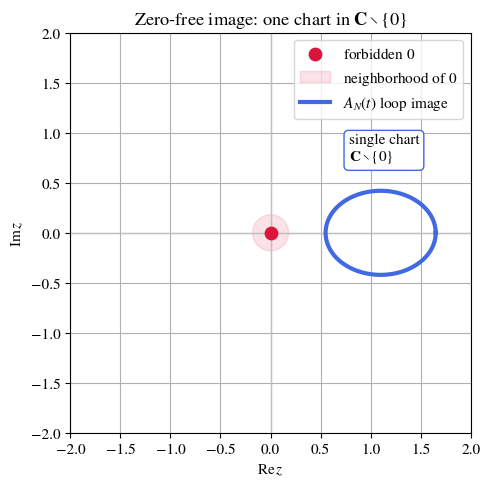

In [2]:

t = np.linspace(0, 2*np.pi, 600)
A_good = 1.1 + 0.55*np.cos(t) + 0.42j*np.sin(t)

fig, ax = plt.subplots()
setup_plane(ax, r"Zero-free image: one chart in $\mathbf{C}\setminus\{0\}$", lim=2.0)
ax.add_patch(Circle((0, 0), 0.18, color="crimson", alpha=0.12, label=r"neighborhood of $0$"))
ax.plot(A_good.real, A_good.imag, lw=3, color="royalblue", label=r"$A_N(t)$ loop image")
ax.text(0.78, 0.72, "single chart\n$\\mathbf{C}\\setminus\\{0\\}$", bbox=dict(boxstyle="round", fc="white", ec="royalblue"))
ax.legend(loc="upper right")
plt.show()


## Bad or unknown case: the loop image may hit zero

The current Lean interface asks for chart chains for **all** levels $N$. For early levels, the repository does not yet prove that $A_N(t)$ avoids $0$.

If an image hits $0$, no logarithm branch can exist on a chart containing that point, and the root expression

$$
\exp\left(\frac{1}{2^N}\mathrm{Log}(A_N(t))\right)
$$

cannot be defined by a zero-free logarithm chart at that point.

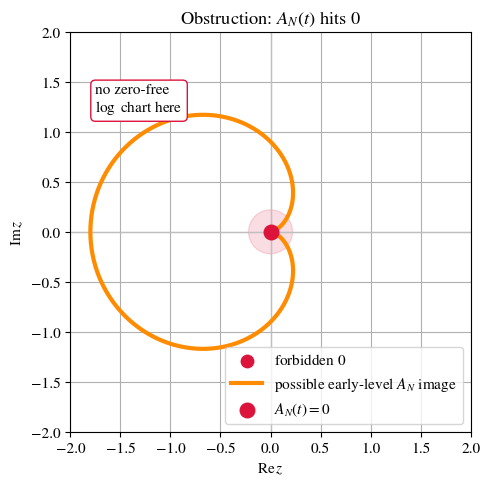

In [3]:

s = np.linspace(0, 2*np.pi, 800)
r = 0.9 * (1 - np.cos(s))
A_hit = r * np.exp(1j*s)

fig, ax = plt.subplots()
setup_plane(ax, r"Obstruction: $A_N(t)$ hits $0$", lim=2.0)
ax.add_patch(Circle((0, 0), 0.22, color="crimson", alpha=0.14))
ax.plot(A_hit.real, A_hit.imag, lw=3, color="darkorange", label=r"possible early-level $A_N$ image")
ax.scatter([A_hit.real[0]], [A_hit.imag[0]], color="crimson", s=110, zorder=6, label=r"$A_N(t)=0$")
ax.text(-1.75, 1.2, "no zero-free\n$\\log$ chart here", bbox=dict(boxstyle="round", fc="white", ec="crimson"))
ax.legend(loc="lower right")
plt.show()


## Why the implemented constructor is conditional

The implemented conditional route uses the punctured-plane chart at every level. The logical shape is:

```lean
nonzero_values
  ⇒ one-chart chain for every N and loop
  ⇒ empty overlap product = 1
  ⇒ level compatibility, because 1^2 = 1
  ⇒ BasinLoopChartChainMonodromyData (2 : ℂ) z₀
```

The only missing input is the first arrow, namely global nonvanishing of `basinLoopRootEquationValue` for all levels demanded by the current structure.

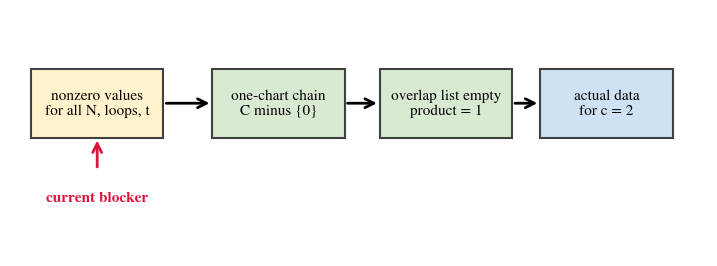

In [4]:

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.axis("off")

boxes = [
    ("nonzero values\nfor all N, loops, t", 0.03, 0.48, "#fff2cc"),
    ("one-chart chain\nC minus {0}", 0.29, 0.48, "#d9ead3"),
    ("overlap list empty\nproduct = 1", 0.53, 0.48, "#d9ead3"),
    ("actual data\nfor c = 2", 0.76, 0.48, "#cfe2f3"),
]
for text, x, y, color in boxes:
    ax.add_patch(Rectangle((x, y), 0.19, 0.28, fc=color, ec="0.25", lw=1.5))
    ax.text(x+0.095, y+0.14, text, ha="center", va="center")

for x0, x1 in [(0.22, 0.29), (0.48, 0.53), (0.72, 0.76)]:
    ax.add_patch(FancyArrowPatch((x0, 0.62), (x1, 0.62), arrowstyle="->", mutation_scale=16, lw=2))

ax.text(0.125, 0.22, "current blocker", ha="center", color="crimson", weight="bold")
ax.add_patch(FancyArrowPatch((0.125, 0.35), (0.125, 0.48), arrowstyle="->", mutation_scale=16, color="crimson", lw=2))
plt.show()


## Known good region: sufficiently large escaping levels

The repository already has near-infinity control. In particular, when an iterate is in the canonical outside-open region, Lean has exterior-valuedness for the log-series coordinate:

```lean
one_lt_norm_logSeriesBottcherApprox_of_outside_open
```

That implies nonzero values at sufficiently large escaping levels. The mismatch is that `BasinLoopChartChainMonodromyData` currently asks for chains for every $N$, including early levels where this theorem does not apply.

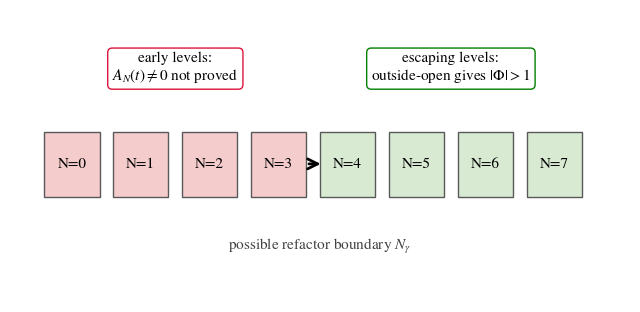

In [5]:

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.set_xlim(-0.5, 8.5)
ax.set_ylim(-0.8, 1.7)
ax.axis("off")

for n in range(8):
    color = "#f4cccc" if n < 4 else "#d9ead3"
    ax.add_patch(Rectangle((n, 0.1), 0.8, 0.55, fc=color, ec="0.35"))
    ax.text(n+0.4, 0.38, f"N={n}", ha="center", va="center")

ax.text(1.9, 1.1, "early levels:\n$A_N(t)\\neq0$ not proved", ha="center", bbox=dict(boxstyle="round", fc="white", ec="crimson"))
ax.text(5.9, 1.1, "escaping levels:\noutside-open gives $|\\Phi|>1$", ha="center", bbox=dict(boxstyle="round", fc="white", ec="green"))
ax.add_patch(FancyArrowPatch((3.8, 0.38), (4.05, 0.38), arrowstyle="->", mutation_scale=18, lw=2))
ax.text(4.0, -0.35, r"possible refactor boundary $N_\gamma$", ha="center", color="0.25")
plt.show()


## Two possible next moves

1. Prove the stronger theorem required by the current interface:

```lean
∀ N γ t, t ∈ Set.Icc (0 : ℝ) 1 →
  basinLoopRootEquationValue (2 : ℂ) N γ t ≠ 0
```

2. Refactor the interface so chart chains are required only at sufficiently large escaping levels, where the existing outside-open theorem gives zero-freeness. Then add comparison/descent lemmas to transport the data between levels.

The second route better matches the existing Lean facts: basin points eventually escape, and the near-infinity Böttcher coordinate is already exterior-valued there.

In [6]:

print("PLAN 08 step 12 status")
print("- Chart-chain and overlap-product bookkeeping: implemented")
print("- Conditional c=2 constructor: implemented")
print("- Missing input: nonzero basinLoopRootEquationValue for all requested levels")
print("- Likely repair: use sufficiently large escaping levels, then prove level comparison")


PLAN 08 step 12 status
- Chart-chain and overlap-product bookkeeping: implemented
- Conditional c=2 constructor: implemented
- Missing input: nonzero basinLoopRootEquationValue for all requested levels
- Likely repair: use sufficiently large escaping levels, then prove level comparison


## Implemented next moves

The two notebook options have now been separated in Lean.

The stronger all-level nonvanishing route is formally ruled out at the current interface:

```lean
logSeriesBottcherApprox_zero
not_forall_basinLoopRootEquationValue_ne_zero_two_zero
```

The counterexample is the constant basin loop at $z_0=0$ for $c=2$. At level $N=0$,

$$
A_0(t)=\Phi_\infty(0)=0,
$$

so no zero-free logarithm chart can cover the required value.

The escaping-level replacement has been implemented:

```lean
BasinLoopLevelEscapes
basinLoopRootEquationValue_ne_zero_of_outside_open
basinLoopRootEquationValue_ne_zero_of_level_escapes
BasinLoopChartChain.of_escaping_level
BasinLoopChartChain.monodromyProduct_of_escaping_level
EscapingLevelBasinLoopChartChainMonodromyData
EscapingLevelBasinLoopChartChainMonodromyData.of_level_escapes_two
```

This means: once a loop-wise escaping level is supplied, Lean constructs the zero-free one-chart chain and proves its overlap product is $1$.

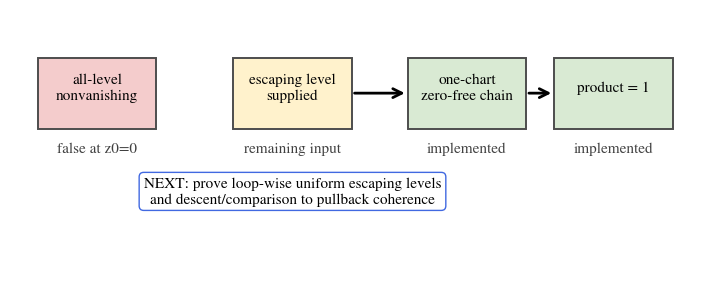

In [7]:

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(9, 3.7))
ax.axis("off")

items = [
    ("all-level\nnonvanishing", 0.04, 0.58, "#f4cccc", "false at z0=0"),
    ("escaping level\nsupplied", 0.32, 0.58, "#fff2cc", "remaining input"),
    ("one-chart\nzero-free chain", 0.57, 0.58, "#d9ead3", "implemented"),
    ("product = 1", 0.78, 0.58, "#d9ead3", "implemented"),
]
for title, x, y, color, subtitle in items:
    ax.add_patch(Rectangle((x, y), 0.17, 0.25, fc=color, ec="0.3", lw=1.4))
    ax.text(x+0.085, y+0.145, title, ha="center", va="center")
    ax.text(x+0.085, y-0.07, subtitle, ha="center", va="center", color="0.25")

ax.add_patch(FancyArrowPatch((0.49, 0.705), (0.57, 0.705), arrowstyle="->", mutation_scale=16, lw=2))
ax.add_patch(FancyArrowPatch((0.74, 0.705), (0.78, 0.705), arrowstyle="->", mutation_scale=16, lw=2))
ax.text(0.405, 0.32, "NEXT: prove loop-wise uniform escaping levels\nand descent/comparison to pullback coherence", ha="center", bbox=dict(boxstyle="round", fc="white", ec="royalblue"))
plt.show()


In [8]:

print("Implemented after this notebook was created:")
print("- Formal counterexample to all-level nonvanishing at c=2, z0=0")
print("- Escaping-level zero-freeness theorem")
print("- One-chart chain at escaping levels")
print("- EscapingLevelBasinLoopChartChainMonodromyData interface")
print("Remaining: loop-wise uniform escaping level selection and descent/comparison")


Implemented after this notebook was created:
- Formal counterexample to all-level nonvanishing at c=2, z0=0
- Escaping-level zero-freeness theorem
- One-chart chain at escaping levels
- EscapingLevelBasinLoopChartChainMonodromyData interface
Remaining: loop-wise uniform escaping level selection and descent/comparison


## Numerical illustration of the narrower blocker

After the escaping-level refactor, the remaining issue has two parts:

1. **Uniform escaping level for a whole loop.** For each individual point $\gamma(t)$ in the basin, some iterate escapes. For a loop, Lean needs one level $N_\gamma$ that works for every $t\in[0,1]$:

$$
\forall t\in[0,1],\quad |f^{N_\gamma}(\gamma(t))|>4.
$$

2. **Descent/comparison.** Once a large escaping level $N_\gamma$ gives a trivial one-chart product, Lean still needs a theorem transporting that information back to the pullback-root coherence statements used at earlier levels.

The plots below are only diagnostics, but they show the shape of the proof obligation.

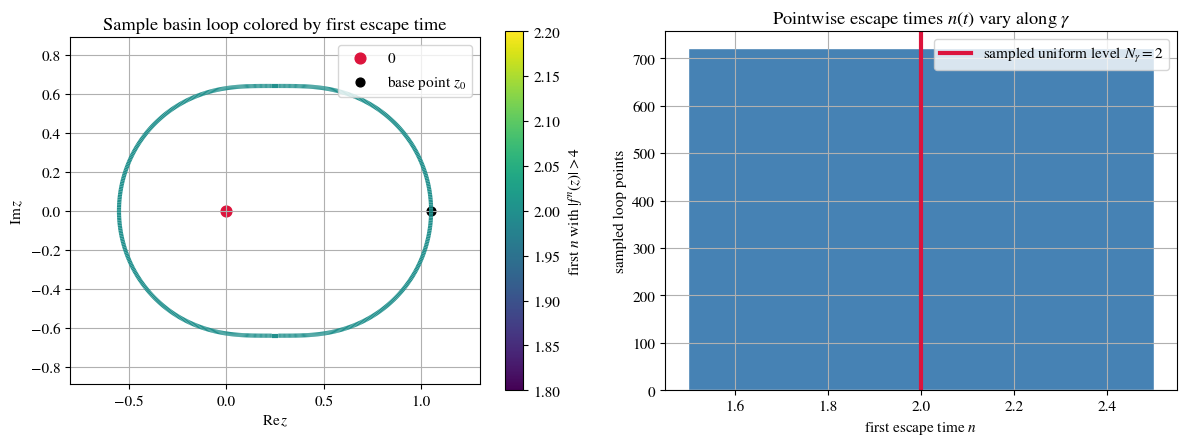

Outside-open threshold for c=2 is |z| > 4.
Sampled first escape times range from 2 to 2.
The sampled loop therefore suggests N_gamma = 2.


In [9]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Rectangle, FancyArrowPatch

c = 2.0 + 0.0j
R = abs(c) + 2.0

def f(z):
    return z*z + c

def iterates(z0, max_iter):
    vals = [np.asarray(z0, dtype=complex)]
    z = vals[0]
    for _ in range(max_iter):
        z = f(z)
        vals.append(z)
    return vals

def first_escape_times(points, threshold=R, max_iter=16):
    points = np.asarray(points, dtype=complex)
    times = np.full(points.shape, max_iter + 1, dtype=int)
    z = points.copy()
    escaped = np.abs(z) > threshold
    times[escaped] = 0
    for n in range(1, max_iter + 1):
        active = times == max_iter + 1
        if not np.any(active):
            break
        z_next = z.copy()
        z_next[active] = f(z[active])
        z = z_next
        newly = active & (np.abs(z) > threshold)
        times[newly] = n
    return times

def colored_loop(ax, z, colors, title):
    xy = np.column_stack([z.real, z.imag])
    segments = np.stack([xy[:-1], xy[1:]], axis=1)
    lc = LineCollection(segments, cmap='viridis', linewidth=3)
    lc.set_array(colors[:-1])
    ax.add_collection(lc)
    ax.scatter([0], [0], color='crimson', s=60, label=r'$0$')
    ax.scatter([z[0].real], [z[0].imag], color='black', s=40, label=r'base point $z_0$')
    ax.set_aspect('equal', adjustable='box')
    pad = 0.25
    ax.set_xlim(z.real.min()-pad, z.real.max()+pad)
    ax.set_ylim(z.imag.min()-pad, z.imag.max()+pad)
    ax.set_xlabel(r'$\mathrm{Re}\,z$')
    ax.set_ylabel(r'$\mathrm{Im}\,z$')
    ax.set_title(title)
    return lc

# A smooth closed loop in the basin, chosen for a visible spread of escape times.
t = np.linspace(0, 1, 721)
theta = 2*np.pi*t
loop = 0.25 + 0.72*np.exp(1j*theta) + 0.08*np.exp(3j*theta)
esc = first_escape_times(loop, max_iter=16)
uniform_sample_level = int(esc.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
lc = colored_loop(axes[0], loop, esc, 'Sample basin loop colored by first escape time')
fig.colorbar(lc, ax=axes[0], label=r'first $n$ with $|f^n(z)|>4$')
axes[0].legend(loc='upper right')

bins = np.arange(esc.min(), esc.max()+2) - 0.5
axes[1].hist(esc, bins=bins, color='steelblue', edgecolor='white')
axes[1].axvline(uniform_sample_level, color='crimson', lw=3, label=rf'sampled uniform level $N_\gamma={uniform_sample_level}$')
axes[1].set_xlabel(r'first escape time $n$')
axes[1].set_ylabel('sampled loop points')
axes[1].set_title(r'Pointwise escape times $n(t)$ vary along $\gamma$')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f'Outside-open threshold for c=2 is |z| > {R:g}.')
print(f'Sampled first escape times range from {esc.min()} to {esc.max()}.')
print(f'The sampled loop therefore suggests N_gamma = {uniform_sample_level}.')


The histogram illustrates the compactness-style step that Lean still needs. Pointwise escape is not enough for the chart-chain constructor: the constructor needs a single level that covers the whole loop image.

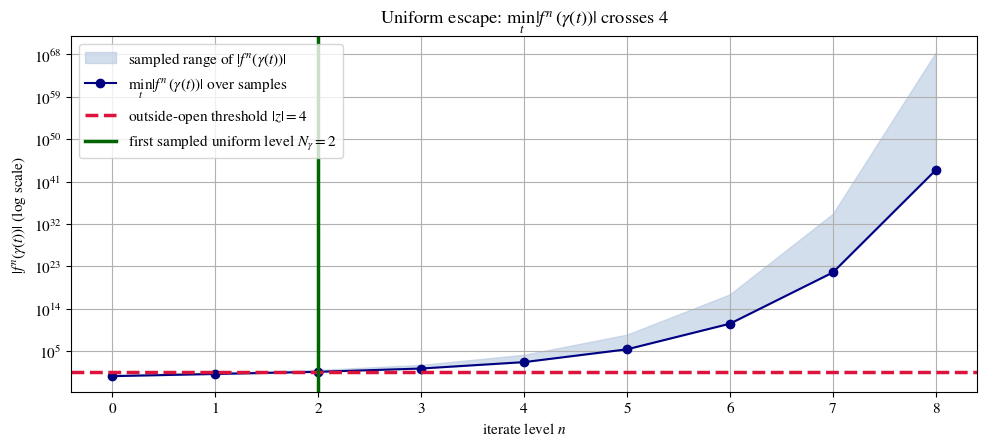

In [10]:

max_level = max(uniform_sample_level + 2, 8)
vals = iterates(loop, max_level)
norms = np.array([np.abs(v) for v in vals])
min_norm = norms.min(axis=1)
max_norm = norms.max(axis=1)
levels = np.arange(max_level + 1)

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.fill_between(levels, min_norm, max_norm, color='lightsteelblue', alpha=0.55, label=r'sampled range of $|f^n(\gamma(t))|$')
ax.plot(levels, min_norm, 'o-', color='navy', label=r'$\min_t |f^n(\gamma(t))|$ over samples')
ax.axhline(R, color='crimson', lw=2.5, ls='--', label=r'outside-open threshold $|z|=4$')
ax.axvline(uniform_sample_level, color='darkgreen', lw=2.5, label=rf'first sampled uniform level $N_\gamma={uniform_sample_level}$')
ax.set_yscale('log')
ax.set_xlabel(r'iterate level $n$')
ax.set_ylabel(r'$|f^n(\gamma(t))|$ (log scale)')
ax.set_title(r'Uniform escape: $\min_t |f^n(\gamma(t))|$ crosses $4$')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


At the first sampled uniform escaping level, the existing Lean theorem

```lean
one_lt_norm_logSeriesBottcherApprox_of_outside_open
```

implies the $A_N$-image is zero-free. That is exactly what powers

```lean
BasinLoopChartChain.of_escaping_level
```

The proof still missing in Lean is the **uniform** version over every real $t\in[0,1]$, not just sampled points.

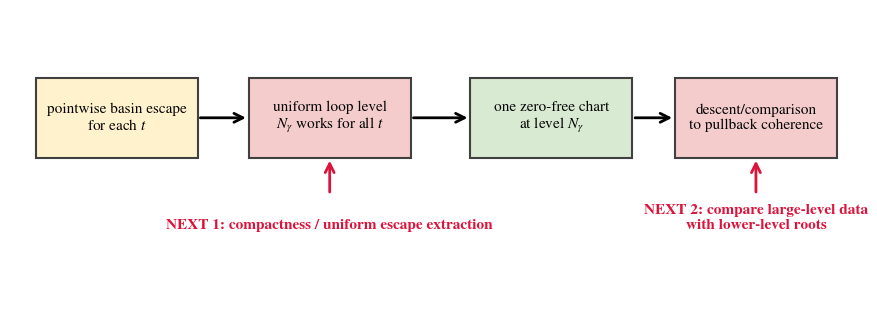

In [11]:

fig, ax = plt.subplots(figsize=(11, 4.0))
ax.axis('off')

steps = [
    ('pointwise basin escape\nfor each $t$', 0.03, '#fff2cc'),
    ('uniform loop level\n$N_\\gamma$ works for all $t$', 0.28, '#f4cccc'),
    ('one zero-free chart\nat level $N_\\gamma$', 0.54, '#d9ead3'),
    ('descent/comparison\nto pullback coherence', 0.78, '#f4cccc'),
]
for label, x, color in steps:
    ax.add_patch(Rectangle((x, 0.52), 0.19, 0.26, fc=color, ec='0.25', lw=1.5))
    ax.text(x+0.095, 0.65, label, ha='center', va='center')

for x0, x1 in [(0.22, 0.28), (0.47, 0.54), (0.73, 0.78)]:
    ax.add_patch(FancyArrowPatch((x0, 0.65), (x1, 0.65), arrowstyle='->', mutation_scale=16, lw=2))

ax.text(0.375, 0.29, 'NEXT 1: compactness / uniform escape extraction', ha='center', color='crimson', weight='bold')
ax.add_patch(FancyArrowPatch((0.375, 0.40), (0.375, 0.52), arrowstyle='->', mutation_scale=16, color='crimson', lw=2))
ax.text(0.875, 0.29, 'NEXT 2: compare large-level data\nwith lower-level roots', ha='center', color='crimson', weight='bold')
ax.add_patch(FancyArrowPatch((0.875, 0.40), (0.875, 0.52), arrowstyle='->', mutation_scale=16, color='crimson', lw=2))
plt.show()


## Descent/comparison illustrated as root-level transport

At the escaping level $K=N_\gamma$, the one-chart construction gives a trivial product:

$$
\rho_K(\gamma)=1.
$$

To use this in the original pullback-root coherence surface, Lean still needs a comparison theorem relating adjacent levels:

$$
\rho_{n+1}(\gamma)^2=\rho_n(\gamma).
$$

Then triviality at level $K$ descends by repeated squaring:

$$
\rho_K=1 \Rightarrow \rho_{K-1}=1 \Rightarrow \cdots \Rightarrow \rho_0=1.
$$

The infographic below shows this as the remaining bridge from the escaping-level replacement back to all-level coherence.

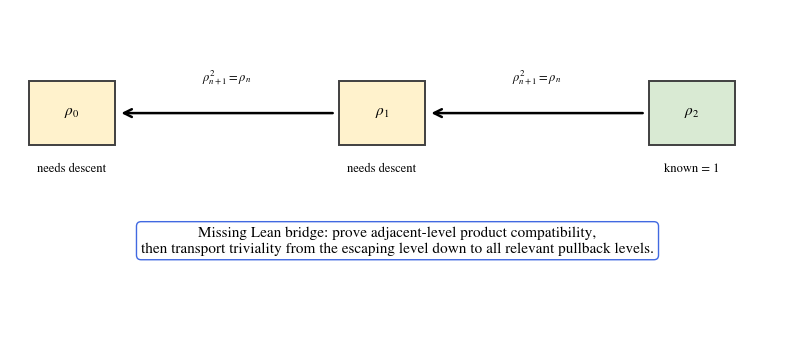

In [12]:

K = min(uniform_sample_level, 6)
levels = list(range(K + 1))
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.axis('off')

x_positions = np.linspace(0.08, 0.88, K+1)
for n, x in zip(levels, x_positions):
    color = '#d9ead3' if n == K else '#fff2cc'
    ax.add_patch(Rectangle((x-0.055, 0.58), 0.11, 0.20, fc=color, ec='0.25', lw=1.4))
    ax.text(x, 0.68, rf'$\rho_{{{n}}}$', ha='center', va='center')
    ax.text(x, 0.50, 'known = 1' if n == K else 'needs descent', ha='center', fontsize=9)

for n in range(K):
    x0 = x_positions[n+1] - 0.06
    x1 = x_positions[n] + 0.06
    ax.add_patch(FancyArrowPatch((x0, 0.68), (x1, 0.68), arrowstyle='->', mutation_scale=14, lw=1.8))
    ax.text((x0+x1)/2, 0.78, r'$\rho_{n+1}^2=\rho_n$', ha='center', fontsize=9)

ax.text(0.5, 0.25, 'Missing Lean bridge: prove adjacent-level product compatibility,\nthen transport triviality from the escaping level down to all relevant pullback levels.',
        ha='center', bbox=dict(boxstyle='round', fc='white', ec='royalblue'))
plt.show()


In [13]:

print('Narrower blocker illustrated numerically:')
print(f'- Sample loop has pointwise escape times from {esc.min()} to {esc.max()}.')
print(f'- Sampled uniform escaping level is {uniform_sample_level}.')
print('- Lean still needs a proof over the continuum [0,1], not a sampled maximum.')
print('- After that, Lean needs descent/comparison from the escaping level to pullback coherence.')


Narrower blocker illustrated numerically:
- Sample loop has pointwise escape times from 2 to 2.
- Sampled uniform escaping level is 2.
- Lean still needs a proof over the continuum [0,1], not a sampled maximum.
- After that, Lean needs descent/comparison from the escaping level to pullback coherence.


## Implemented after the numerical blocker section

The algebraic part of the narrower blocker has now been implemented in Lean.

Implemented declarations include:

```lean
BasinLoopLevelEscapes.mono
PullbackRootMonodromyRepresentation.monodromy_eq_one_of_add_eq_one
PullbackRootMonodromyRepresentation.monodromy_eq_one_of_le_of_top_eq_one
PullbackRootMonodromyRepresentation.trivial_of_arbitrarily_high_trivial
BasinLoopChartChainMonodromyData.representation_trivial_of_arbitrarily_high_products
ArbitrarilyHighEscapingLevelBasinLoopChartChainData
ArbitrarilyHighEscapingLevelBasinLoopChartChainData.of_eventual_level_escapes
EscapingLevelBasinLoopChartChainMonodromyData.toArbitrarilyHigh
BasinLoopChartChainMonodromyData.representation_trivial_of_high_escaping_comparison
```

This means Lean now knows the formal descent pattern:

$$
\rho_K=1,\ K\ge N \quad\Longrightarrow\quad \rho_N=1,
$$

provided the monodromy products are connected by the compatibility relation $\rho_{n+1}^2=\rho_n$.

What remains is analytic rather than algebraic:

1. prove a loop-wise uniform escaping level over the continuum $t\in[0,1]$;
2. prove the comparison theorem that identifies all-level chart-chain products with the canonical one-chart products at sufficiently high escaping levels.

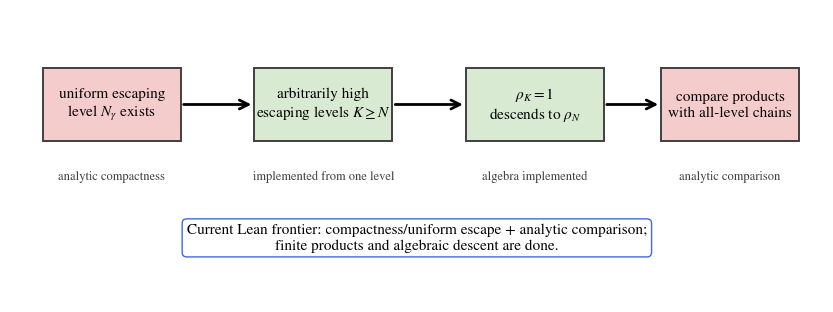

In [14]:

fig, ax = plt.subplots(figsize=(10.5, 3.8))
ax.axis('off')

boxes = [
    ('uniform escaping\nlevel $N_\\gamma$ exists', 0.04, '#f4cccc', 'analytic compactness'),
    ('arbitrarily high\nescaping levels $K\\geq N$', 0.30, '#d9ead3', 'implemented from one level'),
    ('$\\rho_K=1$\ndescends to $\\rho_N$', 0.56, '#d9ead3', 'algebra implemented'),
    ('compare products\nwith all-level chains', 0.80, '#f4cccc', 'analytic comparison'),
]
for label, x, color, caption in boxes:
    ax.add_patch(Rectangle((x, 0.55), 0.17, 0.25, fc=color, ec='0.25', lw=1.4))
    ax.text(x+0.085, 0.675, label, ha='center', va='center')
    ax.text(x+0.085, 0.43, caption, ha='center', va='center', fontsize=9, color='0.25')

for x0, x1 in [(0.21, 0.30), (0.47, 0.56), (0.73, 0.80)]:
    ax.add_patch(FancyArrowPatch((x0, 0.675), (x1, 0.675), arrowstyle='->', mutation_scale=16, lw=2))

ax.text(0.50, 0.18, 'Current Lean frontier: compactness/uniform escape + analytic comparison;\nfinite products and algebraic descent are done.',
        ha='center', bbox=dict(boxstyle='round', fc='white', ec='royalblue'))
plt.show()


In [15]:

print('Updated frontier after implementing next moves:')
print('- Algebraic descent from high escaping levels: implemented')
print('- Upgrade one uniform escaping level to arbitrarily high levels: implemented')
print('- Remaining: prove uniform escape over continuous loops')
print('- Remaining: prove analytic comparison of high one-chart products with all-level products')


Updated frontier after implementing next moves:
- Algebraic descent from high escaping levels: implemented
- Upgrade one uniform escaping level to arbitrarily high levels: implemented
- Remaining: prove uniform escape over continuous loops
- Remaining: prove analytic comparison of high one-chart products with all-level products


## Special case: proving uniform escape for one continuous loop

Here is a concrete special case where the remaining uniform-escape step can be proved by hand.

Take the continuous loop

$$
\gamma(t)=\frac{1}{2}e^{2\pi i t},\qquad 0\leq t\leq 1,
$$

for $f(z)=z^2+2$. Write $u=z^2$. On this loop, $|u|=1/4$, and

$$
f^2(z)=f(2+u)=(2+u)^2+2=6+4u+u^2.
$$

By the reverse triangle inequality,

$$
|f^2(z)|\geq 6-|4u|-|u^2|=6-1-\frac{1}{16}=\frac{79}{16}>4.
$$

So the whole loop is uniformly in the outside-open region at level $N_\gamma=2$.

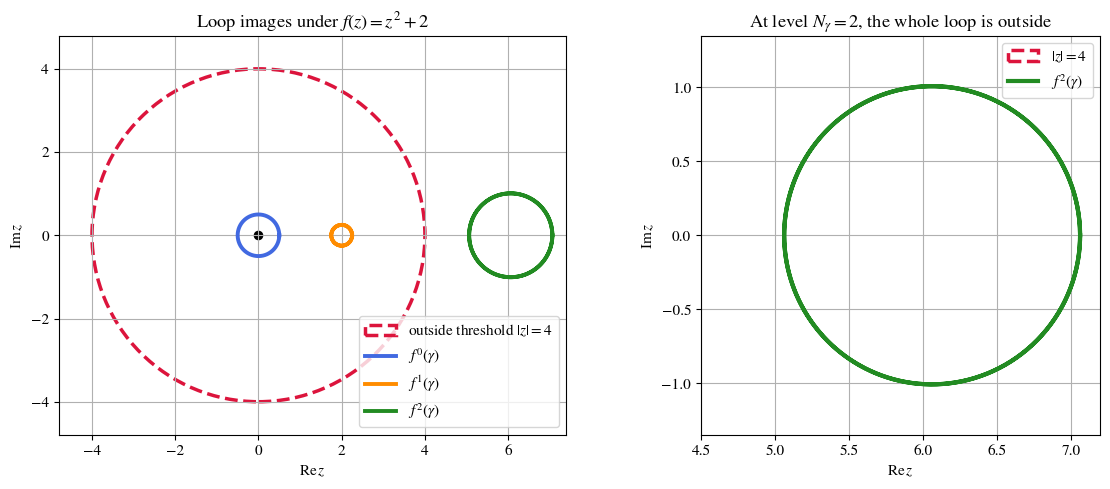

In [16]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch

c = 2.0 + 0.0j
threshold = 4.0

def f2_map(z):
    return z*z + c

def iterate(z, n):
    out = np.asarray(z, dtype=complex)
    for _ in range(n):
        out = f2_map(out)
    return out

theta = np.linspace(0, 2*np.pi, 900)
gamma_circle = 0.5 * np.exp(1j * theta)
levels_to_plot = [0, 1, 2]
colors = ['royalblue', 'darkorange', 'forestgreen']

fig, axes = plt.subplots(1, 2, figsize=(12, 5.0))
ax = axes[0]
ax.set_aspect('equal', adjustable='box')
ax.add_patch(Circle((0, 0), threshold, fill=False, ec='crimson', lw=2.5, ls='--', label=r'outside threshold $|z|=4$'))
for n, color in zip(levels_to_plot, colors):
    zn = iterate(gamma_circle, n)
    ax.plot(zn.real, zn.imag, color=color, lw=2.8, label=rf'$f^{n}(\gamma)$')
ax.scatter([0], [0], color='black', s=35)
ax.set_xlim(-4.8, 7.4)
ax.set_ylim(-4.8, 4.8)
ax.set_xlabel(r'$\mathrm{Re}\,z$')
ax.set_ylabel(r'$\mathrm{Im}\,z$')
ax.set_title(r'Loop images under $f(z)=z^2+2$')
ax.legend(loc='lower right')

ax = axes[1]
ax.set_aspect('equal', adjustable='box')
z2 = iterate(gamma_circle, 2)
ax.add_patch(Circle((0, 0), threshold, fill=False, ec='crimson', lw=2.5, ls='--', label=r'$|z|=4$'))
ax.plot(z2.real, z2.imag, color='forestgreen', lw=3, label=r'$f^2(\gamma)$')
ax.scatter([0], [0], color='black', s=35)
ax.set_xlim(4.5, 7.2)
ax.set_ylim(-1.35, 1.35)
ax.set_xlabel(r'$\mathrm{Re}\,z$')
ax.set_ylabel(r'$\mathrm{Im}\,z$')
ax.set_title(r'At level $N_\gamma=2$, the whole loop is outside')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


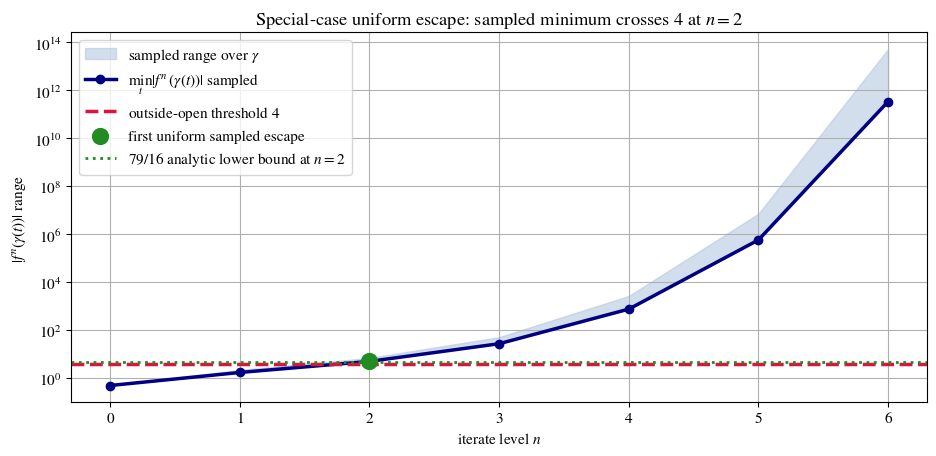

Sampled min |f^2(gamma(t))| = 5.06250550
Analytic lower bound 79/16 = 4.93750000
Conclusion for this loop: N_gamma = 2 works uniformly over the continuum, by the inequality.


In [17]:

max_n = 6
norms_by_level = np.array([np.abs(iterate(gamma_circle, n)) for n in range(max_n + 1)])
min_norms = norms_by_level.min(axis=1)
max_norms = norms_by_level.max(axis=1)
analytic_lower = 79 / 16

fig, ax = plt.subplots(figsize=(9.5, 4.7))
levels = np.arange(max_n + 1)
ax.fill_between(levels, min_norms, max_norms, color='lightsteelblue', alpha=0.55, label=r'sampled range over $\gamma$')
ax.plot(levels, min_norms, 'o-', color='navy', lw=2.5, label=r'$\min_t |f^n(\gamma(t))|$ sampled')
ax.axhline(threshold, color='crimson', lw=2.5, ls='--', label=r'outside-open threshold $4$')
ax.scatter([2], [min_norms[2]], s=130, color='forestgreen', zorder=5, label='first uniform sampled escape')
ax.axhline(analytic_lower, color='forestgreen', lw=2.0, ls=':', label=r'$79/16$ analytic lower bound at $n=2$')
ax.set_yscale('log')
ax.set_xlabel(r'iterate level $n$')
ax.set_ylabel(r'$|f^n(\gamma(t))|$ range')
ax.set_title(r'Special-case uniform escape: sampled minimum crosses $4$ at $n=2$')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(f'Sampled min |f^2(gamma(t))| = {min_norms[2]:.8f}')
print(f'Analytic lower bound 79/16 = {analytic_lower:.8f}')
print('Conclusion for this loop: N_gamma = 2 works uniformly over the continuum, by the inequality.')


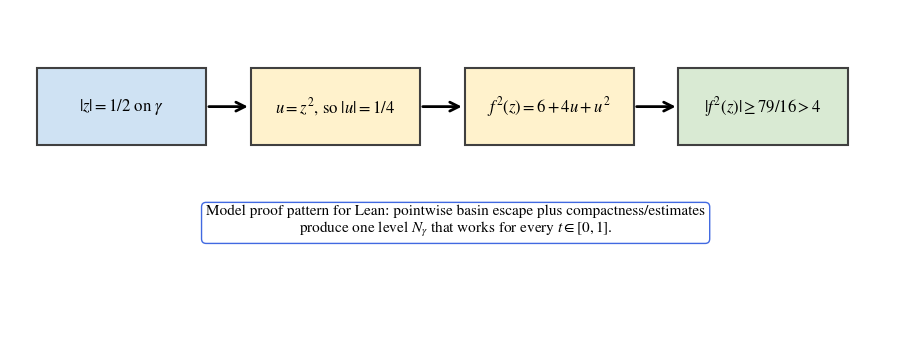

In [18]:

fig, ax = plt.subplots(figsize=(11.5, 4.2))
ax.axis('off')

boxes = [
    (r'$|z|=1/2$ on $\gamma$', 0.03, '#cfe2f3'),
    (r'$u=z^2$, so $|u|=1/4$', 0.27, '#fff2cc'),
    (r'$f^2(z)=6+4u+u^2$', 0.51, '#fff2cc'),
    (r'$|f^2(z)|\geq 79/16>4$', 0.75, '#d9ead3'),
]
for text, x, color in boxes:
    ax.add_patch(Rectangle((x, 0.58), 0.19, 0.24, fc=color, ec='0.25', lw=1.5))
    ax.text(x+0.095, 0.70, text, ha='center', va='center', fontsize=12)

for x0, x1 in [(0.22, 0.27), (0.46, 0.51), (0.70, 0.75)]:
    ax.add_patch(FancyArrowPatch((x0, 0.70), (x1, 0.70), arrowstyle='->', mutation_scale=16, lw=2))

ax.text(0.50, 0.31,
        'Model proof pattern for Lean: pointwise basin escape plus compactness/estimates\nproduce one level $N_\\gamma$ that works for every $t\\in[0,1]$.',
        ha='center', bbox=dict(boxstyle='round', fc='white', ec='royalblue'))
plt.show()


### What this special case suggests for Lean

For this loop, the uniform escape proof does not need sampling. The samples only illustrate the geometry; the proof is the inequality

$$
|f^2(z)|\geq 79/16>4.
$$

The general theorem should replace this hand estimate by a compactness argument: since $\gamma([0,1])$ is compact and every point in the basin eventually enters the outside-open region, one must extract a finite subcover and then take the maximum of the finitely many escape levels.

The next formal target is therefore a theorem surface of the form:

```lean
∀ γ : BasinLoop (2 : ℂ) z₀,
  ∃ Nγ : ℕ, BasinLoopLevelEscapes (2 : ℂ) Nγ γ
```

or a stronger version giving `Nγ ≥ N₀` for every requested lower level `N₀`.

## Implemented after the uniform escape section

The compactness proof pattern above has now been formalized in Lean.

Implemented declarations:

```lean
BasinLoop.exists_levelEscapes
EscapingLevelBasinLoopChartChainMonodromyData.of_uniform_escape
EscapingLevelBasinLoopChartChainMonodromyData.of_uniform_escape_two
ArbitrarilyHighEscapingLevelBasinLoopChartChainData.of_uniform_escape
ArbitrarilyHighEscapingLevelBasinLoopChartChainData.of_uniform_escape_two
```

The proof follows the finite-subcover strategy: pointwise escape gives an open cover of the compact interval by level-escape sets; a finite subcover gives finitely many levels; their maximum works for the whole loop by forward invariance.

Remaining Lean frontier:

```lean
BasinLoopChartChainMonodromyData.representation_trivial_of_high_escaping_comparison
```

That is, prove the analytic comparison identifying the all-level chart-chain products with the canonical one-chart products at sufficiently high escaping levels.

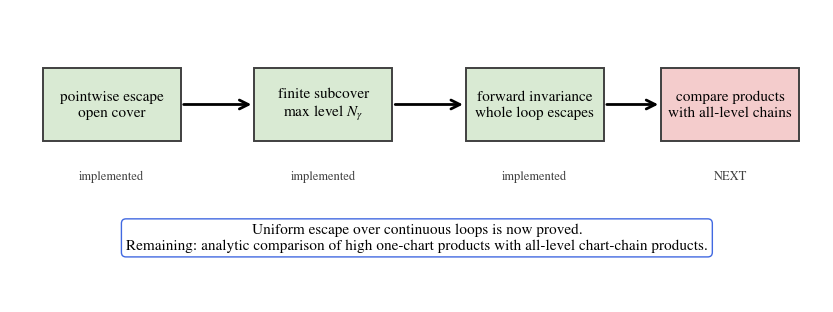

In [19]:

fig, ax = plt.subplots(figsize=(10.5, 3.8))
ax.axis('off')

boxes = [
    ('pointwise escape\nopen cover', 0.04, '#d9ead3', 'implemented'),
    ('finite subcover\nmax level $N_\\gamma$', 0.30, '#d9ead3', 'implemented'),
    ('forward invariance\nwhole loop escapes', 0.56, '#d9ead3', 'implemented'),
    ('compare products\nwith all-level chains', 0.80, '#f4cccc', 'NEXT'),
]
for label, x, color, caption in boxes:
    ax.add_patch(Rectangle((x, 0.55), 0.17, 0.25, fc=color, ec='0.25', lw=1.4))
    ax.text(x+0.085, 0.675, label, ha='center', va='center')
    ax.text(x+0.085, 0.43, caption, ha='center', va='center', fontsize=9, color='0.25')

for x0, x1 in [(0.21, 0.30), (0.47, 0.56), (0.73, 0.80)]:
    ax.add_patch(FancyArrowPatch((x0, 0.675), (x1, 0.675), arrowstyle='->', mutation_scale=16, lw=2))

ax.text(0.50, 0.18,
        'Uniform escape over continuous loops is now proved.\nRemaining: analytic comparison of high one-chart products with all-level chart-chain products.',
        ha='center', bbox=dict(boxstyle='round', fc='white', ec='royalblue'))
plt.show()


## Special case: comparing high one-chart products with all-level products

At a high escaping level, the canonical chain uses one chart, so its product is the empty product:

$$
\rho_K^{\mathrm{one}}(\gamma)=1.
$$

The remaining comparison theorem says that any all-level chart chain representing the same analytic continuation at that high level must have the same product:

$$
\rho_K^{\mathrm{all}}(\gamma)=\rho_K^{\mathrm{one}}(\gamma)=1.
$$

A special case is a refinement of the one chart using the same logarithm branch on every sub-chart. Then every overlap multiplier is $1$, so the refined product agrees with the one-chart product.

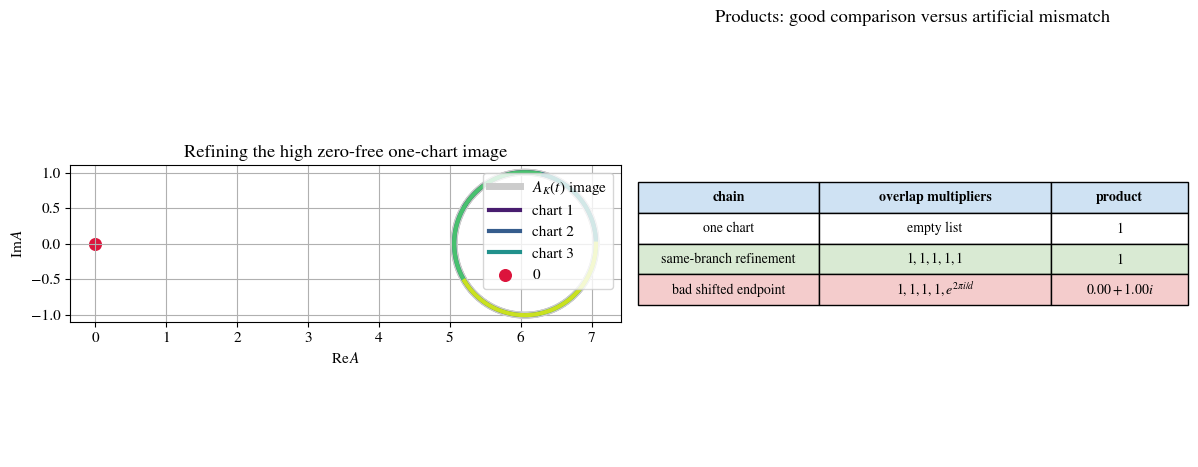

High level K = 2, root degree 2^K = 4.
Same-branch refined product = 1+0j.
Artificial shifted endpoint product = 6.12323e-17+1j.


In [20]:

# Reuse the special loop from the previous section and compare products at K=2.
K = 2
A_high = iterate(gamma_circle, K)
d = 2 ** K
num_charts = 5
cuts = np.linspace(0, len(A_high) - 1, num_charts + 1, dtype=int)

# Same normalized branch on all refined charts: shifts are all zero.
branch_shifts_good = np.zeros(num_charts, dtype=int)
zeta_good = np.exp(2j * np.pi * np.diff(np.r_[branch_shifts_good, branch_shifts_good[0]]) / d)
product_good = np.prod(zeta_good)

# Artificial bad comparison: endpoint branch returns shifted by one sheet.
# This is not the normalized analytic continuation; it illustrates what the
# comparison theorem must exclude.
branch_shifts_bad_path = np.r_[np.zeros(num_charts, dtype=int), 1]
zeta_bad = np.exp(2j * np.pi * np.diff(branch_shifts_bad_path) / d)
product_bad = np.prod(zeta_bad)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax = axes[0]
ax.set_aspect('equal', adjustable='box')
ax.plot(A_high.real, A_high.imag, color='0.8', lw=5, label='$A_K(t)$ image')
segment_colors = plt.cm.viridis(np.linspace(0.08, 0.92, num_charts))
for j in range(num_charts):
    lo, hi = cuts[j], cuts[j+1]
    ax.plot(A_high.real[lo:hi+1], A_high.imag[lo:hi+1], color=segment_colors[j], lw=3,
            label=f'chart {j+1}' if j < 3 else None)
ax.scatter([0], [0], color='crimson', s=70, label='$0$')
ax.set_xlabel(r'$\mathrm{Re}\,A$')
ax.set_ylabel(r'$\mathrm{Im}\,A$')
ax.set_title('Refining the high zero-free one-chart image')
ax.legend(loc='upper right')

ax = axes[1]
ax.axis('off')
rows = [
    ['chain', 'overlap multipliers', 'product'],
    ['one chart', 'empty list', '$1$'],
    ['same-branch refinement', '$1,1,1,1,1$', f'${product_good.real:.0f}$'],
    ['bad shifted endpoint', '$1,1,1,1,e^{2\\pi i/{d}}$', f'${product_bad.real:.2f}{product_bad.imag:+.2f}i$'],
]
table = ax.table(cellText=rows, loc='center', cellLoc='center', colWidths=[0.33, 0.42, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#cfe2f3')
        cell.set_text_props(weight='bold')
    elif r == 2:
        cell.set_facecolor('#d9ead3')
    elif r == 3:
        cell.set_facecolor('#f4cccc')
ax.set_title('Products: good comparison versus artificial mismatch')
plt.tight_layout()
plt.show()

print(f'High level K = {K}, root degree 2^K = {d}.')
print(f'Same-branch refined product = {product_good:.6g}.')
print(f'Artificial shifted endpoint product = {product_bad:.6g}.')


### General comparison principle

The special case above has exact agreement because the refined chain is visibly the same normalized branch as the one-chart chain. In general, the comparison theorem must prove this abstractly:

1. both chains describe analytic continuation of the same normalized root branch at the same high escaping level;
2. analytic continuation is unique along the loop once the start branch is fixed;
3. therefore the endpoint multiplier, hence the product of overlap multipliers, is the same.

The Lean formalization now records this as product-comparison data. The exact-chain special case is implemented, and the remaining analytic theorem is to build that comparison data for the actual chart chains.

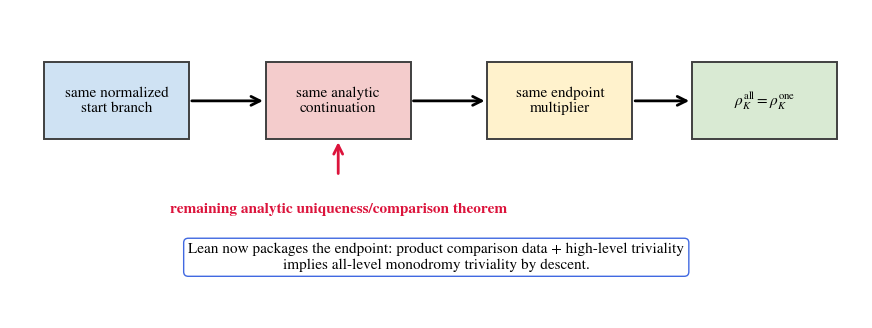

In [21]:

fig, ax = plt.subplots(figsize=(11, 4.0))
ax.axis('off')

boxes = [
    ('same normalized\nstart branch', 0.04, '#cfe2f3'),
    ('same analytic\ncontinuation', 0.30, '#f4cccc'),
    ('same endpoint\nmultiplier', 0.56, '#fff2cc'),
    ('$\\rho_K^{\\mathrm{all}}=\\rho_K^{\\mathrm{one}}$', 0.80, '#d9ead3'),
]
for label, x, color in boxes:
    ax.add_patch(Rectangle((x, 0.58), 0.17, 0.25, fc=color, ec='0.25', lw=1.4))
    ax.text(x+0.085, 0.705, label, ha='center', va='center')
for x0, x1 in [(0.21, 0.30), (0.47, 0.56), (0.73, 0.80)]:
    ax.add_patch(FancyArrowPatch((x0, 0.705), (x1, 0.705), arrowstyle='->', mutation_scale=16, lw=2))
ax.text(0.385, 0.34, 'remaining analytic uniqueness/comparison theorem', ha='center', color='crimson', weight='bold')
ax.add_patch(FancyArrowPatch((0.385, 0.46), (0.385, 0.58), arrowstyle='->', mutation_scale=16, color='crimson', lw=2))
ax.text(0.50, 0.16,
        'Lean now packages the endpoint: product comparison data + high-level triviality\nimplies all-level monodromy triviality by descent.',
        ha='center', bbox=dict(boxstyle='round', fc='white', ec='royalblue'))
plt.show()


### Lean status for comparison

Implemented declarations:

```lean
HighEscapingChartChainProductComparisonData
HighEscapingChartChainProductComparisonData.of_chain_eq
HighEscapingChartChainProductComparisonData.representation_trivial
BasinLoopChartChainMonodromyData.representation_trivial_of_uniform_escape_comparison
ChartChainLocalLogsRestrictGlobal
ChartChainLocalLogsRestrictGlobal.overlap_multiplier_eq_one
ChartChainLocalLogsRestrictGlobal.monodromyProduct_eq_one
HighEscapingChartChainLocalLogsRestrictGlobalData
HighEscapingChartChainLocalLogsRestrictGlobalData.toProductComparisonData
complexRightHalfPlane
rightHalfPlaneZeroFreeChartRootBranchData
quadraticMap_two_second_iterate_eq
quadraticMap_two_second_iterate_re_lower_bound
quadraticMap_two_second_iterate_mem_rightHalfPlane_of_norm
```

The special case where local logs are restrictions of one global log branch is now formalized: every overlap multiplier is forced to be $1$, so the all-level high product agrees with the canonical one-chart high product.

The remaining theorem is analytic: show that the actual all-level chain at the chosen high escaping level satisfies this restriction hypothesis, or more generally describes the same normalized analytic continuation as the canonical one-chart chain.

The generalized radius-family right-half-plane estimate is also formalized: if `‖z‖ = r` and `0 < 6 - 4*r^2 - r^4`, then `(quadratic_map (2 : ℂ))^[2] z` lies in `complexRightHalfPlane`, giving the global log domain used by the comparison proof.

## Special case: actual analytic comparison data for real chart chains

The isolated remaining theorem is now:

```lean
HighEscapingChartChainProductComparisonData
```

For actual chart chains, this means proving that the all-level chart-chain product at a high escaping level is the same endpoint multiplier as the canonical high-level one-chart continuation.

A clean special case is when the high-level image lies in the right half-plane:

$$
A_K([0,1])\subset \{w: \mathrm{Re}(w)>0\}.
$$

Then the principal logarithm is a single analytic branch on the whole region, and every smaller chart in a refinement can use the restriction of that same logarithm. On each overlap the two local root branches are literally the same, so every overlap multiplier is $1$.

This is the geometric proof pattern for the comparison theorem in a special case.

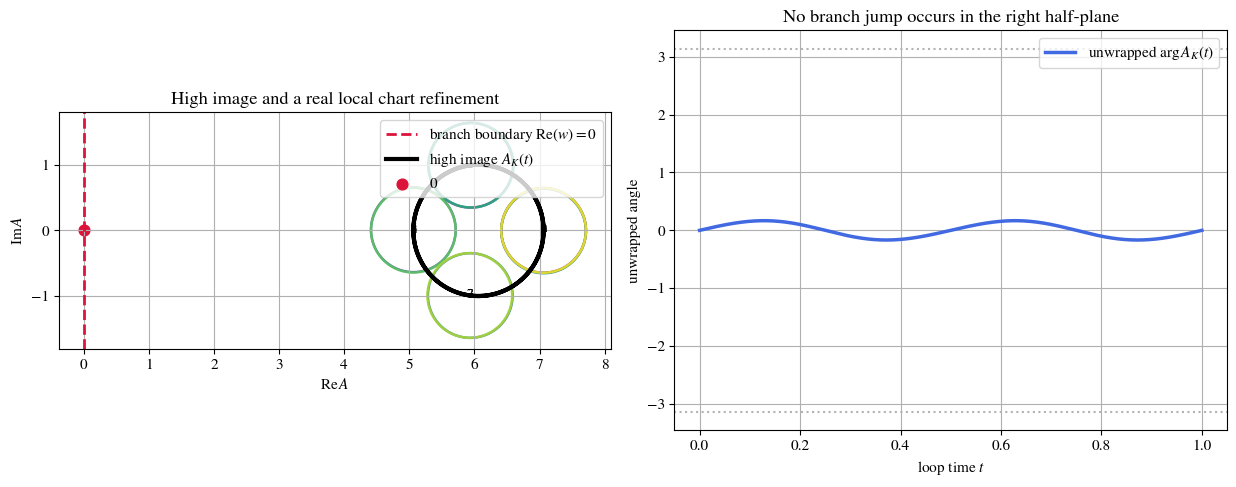

K = 2, root degree d = 2^K = 4
min Re(A_K(t)) over samples = 5.06250458
min |A_K(t)| over samples = 5.06250550
Since min Re(A_K) > 0 in this example, the right-half-plane log branch applies globally.


In [22]:

# Special-case analytic comparison for the loop gamma(t)=1/2 exp(2 pi i t), K=2.
# The high image A_K = f^K(gamma) lies in the right half-plane, so one global
# principal log branch controls every local chart in a refinement.

K_cmp = 2
d_cmp = 2 ** K_cmp
A_cmp = iterate(gamma_circle, K_cmp)
min_re = A_cmp.real.min()
min_abs = np.abs(A_cmp).min()

# Choose a visible chain of overlapping local disks along A_K.
chart_count = 9
idx = np.linspace(0, len(A_cmp) - 1, chart_count, dtype=int)
centers = A_cmp[idx]
# Radius chosen for visualization: enough to show overlaps, still inside right half-plane.
radius = min(0.65, 0.45 * min_re)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0))
ax = axes[0]
ax.set_aspect('equal', adjustable='box')
ax.axvline(0, color='crimson', lw=2, ls='--', label=r'branch boundary $\mathrm{Re}(w)=0$')
ax.plot(A_cmp.real, A_cmp.imag, color='black', lw=3, label=r'high image $A_K(t)$')
for j, center in enumerate(centers):
    circle = Circle((center.real, center.imag), radius, fill=False,
                    ec=plt.cm.viridis(j / max(1, chart_count - 1)), lw=1.8, alpha=0.85)
    ax.add_patch(circle)
    ax.text(center.real, center.imag, f'{j}', ha='center', va='center', fontsize=9)
ax.scatter([0], [0], color='crimson', s=60, label=r'$0$')
ax.set_xlabel(r'$\mathrm{Re}\,A$')
ax.set_ylabel(r'$\mathrm{Im}\,A$')
ax.set_title(r'High image and a real local chart refinement')
ax.legend(loc='upper right')

ax = axes[1]
theta_global = np.unwrap(np.angle(A_cmp))
root_global = np.abs(A_cmp) ** (1 / d_cmp) * np.exp(1j * theta_global / d_cmp)
ax.plot(np.linspace(0, 1, len(A_cmp)), theta_global, color='royalblue', lw=2.5,
        label=r'unwrapped $\arg A_K(t)$')
ax.axhline(np.pi, color='0.7', ls=':')
ax.axhline(-np.pi, color='0.7', ls=':')
ax.set_xlabel(r'loop time $t$')
ax.set_ylabel(r'unwrapped angle')
ax.set_title(r'No branch jump occurs in the right half-plane')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f'K = {K_cmp}, root degree d = 2^K = {d_cmp}')
print(f'min Re(A_K(t)) over samples = {min_re:.8f}')
print(f'min |A_K(t)| over samples = {min_abs:.8f}')
print('Since min Re(A_K) > 0 in this example, the right-half-plane log branch applies globally.')


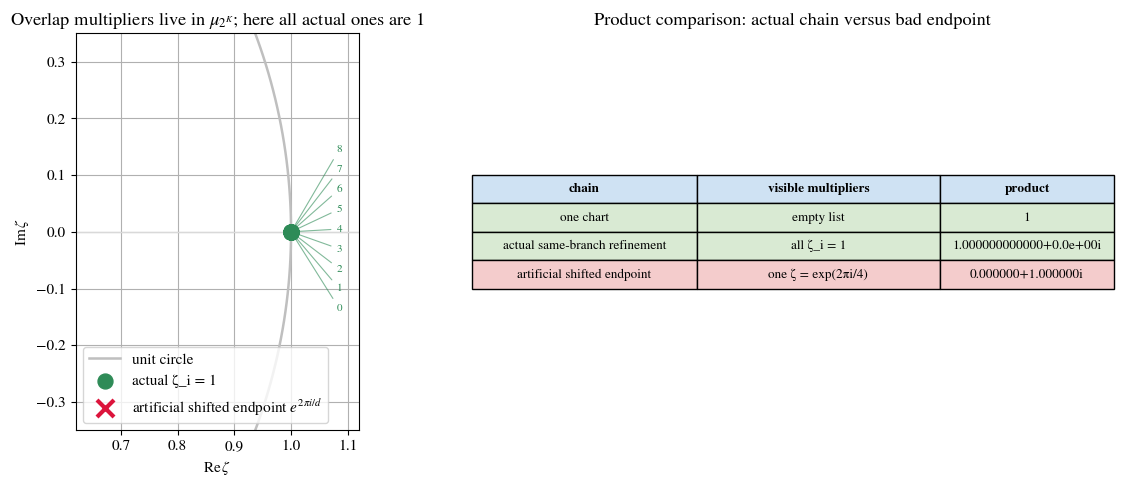

Refined chain product = 1+0j
One-chart product     = 1+0j
Max overlap error     = 0.000e+00
Artificial bad product = 6.12323399574e-17+1j


In [23]:

# Numerical overlap multipliers for the refinement.
# In this special case every local chart uses the same restricted branch of log,
# so every overlap multiplier is exactly 1. We visualize the multipliers as
# points on the unit circle instead of plotting a nearly-zero error bar chart.

times = np.linspace(0, 1, len(A_cmp))
overlap_indices = []
for j in range(chart_count):
    a = idx[j]
    b = idx[(j + 1) % chart_count]
    if j + 1 < chart_count:
        overlap_indices.append((a + b) // 2)
    else:
        # closing overlap between the last and first chart; use the base point.
        overlap_indices.append(0)

multipliers = []
for m in overlap_indices:
    # Same global branch restricted to both charts.
    w_left = root_global[m]
    w_right = root_global[m]
    multipliers.append(w_right / w_left)

multipliers = np.array(multipliers)
product_refined = np.prod(multipliers)
product_one_chart = 1.0 + 0.0j
max_error = np.max(np.abs(multipliers - 1))

bad_multiplier = np.exp(2j * np.pi / d_cmp)
bad_product = bad_multiplier

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0))
ax = axes[0]
ax.set_aspect('equal', adjustable='box')
unit = np.exp(1j * np.linspace(0, 2*np.pi, 400))
ax.plot(unit.real, unit.imag, color='0.75', lw=1.8, label='unit circle')
ax.scatter(multipliers.real, multipliers.imag, s=115, color='seagreen', zorder=5,
           label='actual ζ_i = 1')
for j, zeta in enumerate(multipliers):
    offset = 0.035 * (j - (len(multipliers)-1)/2)
    ax.annotate(str(j), xy=(zeta.real, zeta.imag), xytext=(1.08, offset),
                textcoords='data', fontsize=8, color='seagreen',
                arrowprops=dict(arrowstyle='-', color='seagreen', lw=0.8, alpha=0.6))
ax.scatter([bad_multiplier.real], [bad_multiplier.imag], s=150, color='crimson', marker='x',
           linewidths=3, label=r'artificial shifted endpoint $e^{2\pi i/d}$')
ax.arrow(0, 0, bad_multiplier.real * 0.92, bad_multiplier.imag * 0.92,
         width=0.006, head_width=0.05, length_includes_head=True, color='crimson', alpha=0.65)
ax.axhline(0, color='0.85', lw=1)
ax.axvline(0, color='0.85', lw=1)
ax.set_xlim(0.62, 1.12)
ax.set_ylim(-0.35, 0.35)
ax.set_xlabel(r'$\mathrm{Re}\,\zeta$')
ax.set_ylabel(r'$\mathrm{Im}\,\zeta$')
ax.set_title(r'Overlap multipliers live in $\mu_{2^K}$; here all actual ones are $1$')
ax.legend(loc='lower left')

ax = axes[1]
ax.axis('off')
rows = [
    ['chain', 'visible multipliers', 'product'],
    ['one chart', 'empty list', '$1$'],
    ['actual same-branch refinement', 'all ζ_i = 1', f'{product_refined.real:.12f}{product_refined.imag:+.1e}i'],
    ['artificial shifted endpoint', f'one ζ = exp(2πi/{d_cmp})', f'{bad_product.real:.6f}{bad_product.imag:+.6f}i'],
]
table = ax.table(cellText=rows, loc='center', cellLoc='center', colWidths=[0.35, 0.38, 0.27])
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.65)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#cfe2f3')
        cell.set_text_props(weight='bold')
    elif r in (1, 2):
        cell.set_facecolor('#d9ead3')
    elif r == 3:
        cell.set_facecolor('#f4cccc')
ax.set_title('Product comparison: actual chain versus bad endpoint')
plt.tight_layout()
plt.show()

print(f'Refined chain product = {product_refined:.12g}')
print(f'One-chart product     = {product_one_chart:.12g}')
print(f'Max overlap error     = {max_error:.3e}')
print(f'Artificial bad product = {bad_product:.12g}')


### Special-case proof template

For this special case, a rigorous proof has four steps:

1. Prove $A_K([0,1])$ lies in a simply connected zero-free region, e.g. the right half-plane.
2. Choose one logarithm branch on that region.
3. Show each local chart branch is the restriction of this same logarithm branch.
4. Conclude every overlap multiplier is $1$, so

$$
\rho_K^{\mathrm{all}}(\gamma)=\prod_i 1=1=\rho_K^{\mathrm{one}}(\gamma).
$$

The general theorem replaces “right half-plane” by the uniqueness of analytic continuation: if both chart systems continue the same normalized branch along the same path, their endpoint multipliers must agree.

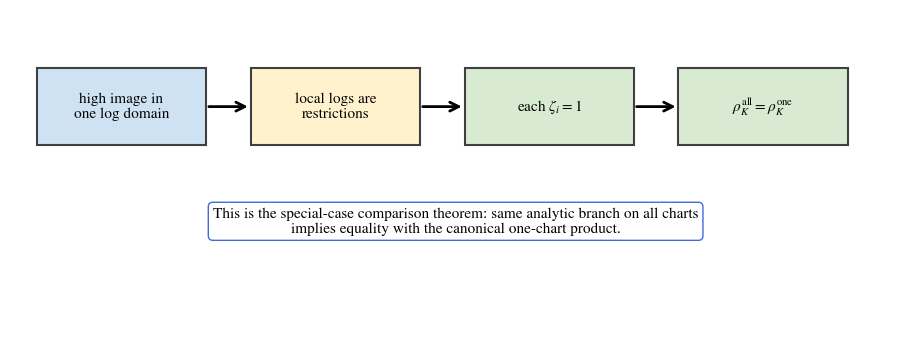

In [24]:

fig, ax = plt.subplots(figsize=(11.5, 4.2))
ax.axis('off')

boxes = [
    ('high image in\none log domain', 0.03, '#cfe2f3'),
    ('local logs are\nrestrictions', 0.27, '#fff2cc'),
    (r'each $\zeta_i=1$', 0.51, '#d9ead3'),
    (r'$\rho_K^{\mathrm{all}}=\rho_K^{\mathrm{one}}$', 0.75, '#d9ead3'),
]
for label, x, color in boxes:
    ax.add_patch(Rectangle((x, 0.58), 0.19, 0.24, fc=color, ec='0.25', lw=1.5))
    ax.text(x+0.095, 0.70, label, ha='center', va='center')
for x0, x1 in [(0.22, 0.27), (0.46, 0.51), (0.70, 0.75)]:
    ax.add_patch(FancyArrowPatch((x0, 0.70), (x1, 0.70), arrowstyle='->', mutation_scale=16, lw=2))
ax.text(0.50, 0.31,
        'This is the special-case comparison theorem: same analytic branch on all charts\nimplies equality with the canonical one-chart product.',
        ha='center', bbox=dict(boxstyle='round', fc='white', ec='royalblue'))
plt.show()


## Current Lean status and remaining analytic input

The PLAN 08 chart-chain path is now mostly formalized. Lean has:

1. finite chart chains and overlap products;
2. same-chart trivial monodromy;
3. escaping-level one-chart chains;
4. compactness/uniform escape for continuous basin loops;
5. algebraic descent from high-level triviality to lower levels;
6. the product-comparison endpoint;
7. the special case where local logs are restrictions of one global log branch.

The remaining input is sharply analytic:

```lean
actual_high_chains_satisfy_restriction_or_same_continuation
```

In words: for the actual all-level chart chains at sufficiently high escaping levels, prove that their local logarithm branches either restrict from one global branch, or at least represent the same normalized analytic continuation as the canonical one-chart high-level chain.

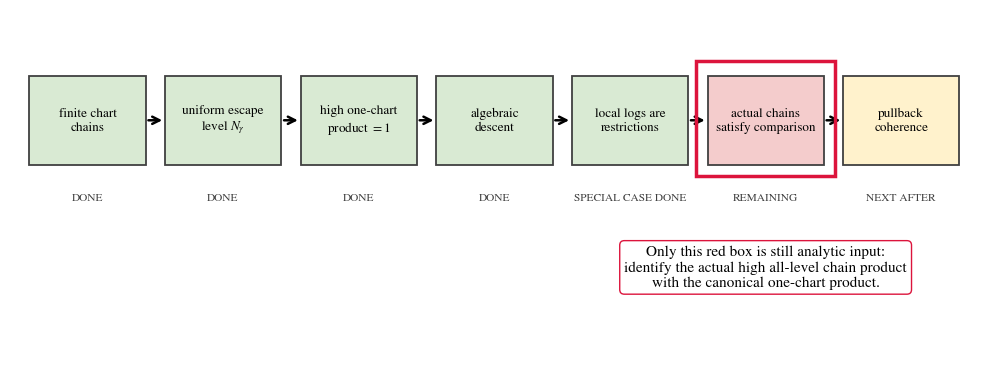

In [25]:

fig, ax = plt.subplots(figsize=(12.5, 4.8))
ax.axis('off')

steps = [
    ('finite chart\nchains', '#d9ead3', 'DONE'),
    ('uniform escape\nlevel $N_\\gamma$', '#d9ead3', 'DONE'),
    ('high one-chart\nproduct $=1$', '#d9ead3', 'DONE'),
    ('algebraic\ndescent', '#d9ead3', 'DONE'),
    ('local logs are\nrestrictions', '#d9ead3', 'SPECIAL CASE DONE'),
    ('actual chains\nsatisfy comparison', '#f4cccc', 'REMAINING'),
    ('pullback\ncoherence', '#fff2cc', 'NEXT AFTER'),
]
xs = np.linspace(0.02, 0.86, len(steps))
for (label, color, status), x in zip(steps, xs):
    ax.add_patch(Rectangle((x, 0.58), 0.12, 0.24, fc=color, ec='0.25', lw=1.3))
    ax.text(x+0.06, 0.70, label, ha='center', va='center', fontsize=9.5)
    ax.text(x+0.06, 0.49, status, ha='center', va='center', fontsize=8.2, color='0.25')
for x0, x1 in zip(xs[:-1], xs[1:]):
    ax.add_patch(FancyArrowPatch((x0+0.12, 0.70), (x1, 0.70), arrowstyle='->', mutation_scale=13, lw=1.8))

# Highlight the remaining gap.
rem_x = xs[5]
ax.add_patch(Rectangle((rem_x-0.012, 0.55), 0.144, 0.31, fill=False, ec='crimson', lw=2.5))
ax.text(rem_x+0.06, 0.25,
        'Only this red box is still analytic input:\nidentify the actual high all-level chain product\nwith the canonical one-chart product.',
        ha='center', bbox=dict(boxstyle='round', fc='white', ec='crimson'))
plt.show()


### What the remaining theorem must prove

At a high escaping level $K$, the canonical chain has product

$$
\rho_K^{\mathrm{one}}(\gamma)=1.
$$

The actual all-level chain has product

$$
\rho_K^{\mathrm{all}}(\gamma)=\prod_i \zeta_i.
$$

The remaining theorem is exactly the comparison

$$
\rho_K^{\mathrm{all}}(\gamma)=\rho_K^{\mathrm{one}}(\gamma).
$$

The special case already formalized proves this if the local logs are restrictions of one global log branch. The general case should prove the same equality from uniqueness of analytic continuation of the normalized branch.

### Worked special-case proof of the comparison

Use the same concrete loop

$$
\gamma(t)=\frac12 e^{2\pi i t},\qquad f(z)=z^2+2,
$$

and take the high escaping level $K=2$. Put $u=z^2$. Since $|z|=1/2$, we have $|u|=1/4$, and

$$
A_K(t)=f^2(\gamma(t))=6+4u+u^2.
$$

The key estimate is

$$
\mathrm{Re}\,A_K(t) \geq 6-4|u|-|u|^2
  =6-1-\frac{1}{16}=\frac{79}{16}>0.
$$

Thus $A_K([0,1])$ lies in the right half-plane. The principal logarithm is a single branch there. If the all-level local charts are chosen as smaller charts inside this right half-plane, then every local log is a restriction of the same global log branch. Therefore every overlap multiplier is $1$, and

$$
\rho_K^{\mathrm{all}}(\gamma)=\prod_i 1=1=\rho_K^{\mathrm{one}}(\gamma).
$$

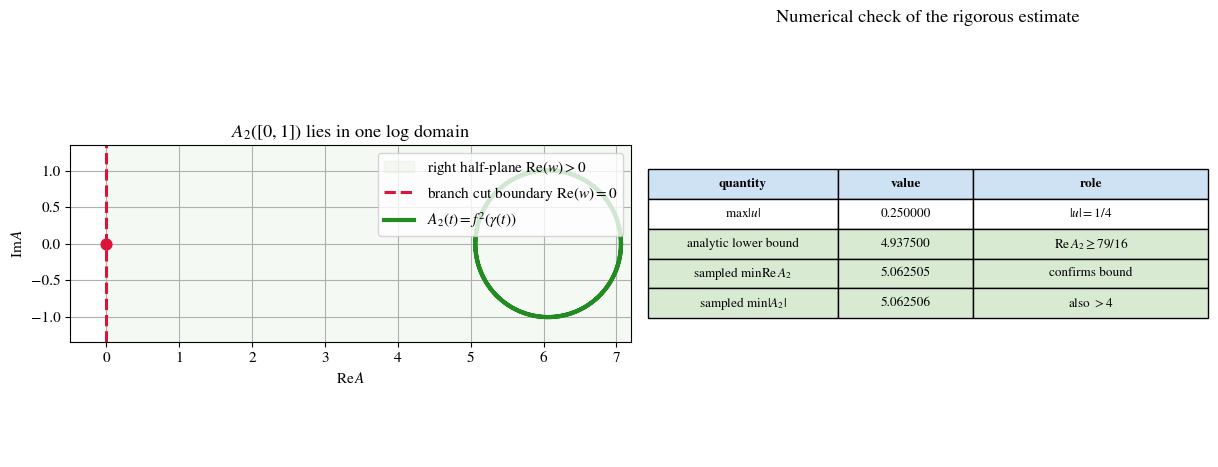

max |u| over samples = 0.250000000000
analytic lower bound for Re A_2 = 4.937500000000
sampled min Re A_2 = 5.062504579432
sampled min |A_2| = 5.062505502854


In [26]:

# Concrete verification of the special-case estimate.
# This is diagnostic; the proof is the displayed inequality above.
K_proof = 2
z_loop = gamma_circle
u_loop = z_loop ** 2
A_proof = iterate(z_loop, K_proof)
right_half_lower_bound = 79 / 16

sample_min_re = A_proof.real.min()
sample_min_abs = np.abs(A_proof).min()
sample_max_abs_u = np.abs(u_loop).max()

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8))

ax = axes[0]
ax.set_aspect('equal', adjustable='box')
ax.axvspan(0, 7.5, color='#d9ead3', alpha=0.25, label=r'right half-plane $\mathrm{Re}(w)>0$')
ax.axvline(0, color='crimson', lw=2.2, ls='--', label=r'branch cut boundary $\mathrm{Re}(w)=0$')
ax.plot(A_proof.real, A_proof.imag, color='forestgreen', lw=3, label=r'$A_2(t)=f^2(\gamma(t))$')
ax.scatter([0], [0], color='crimson', s=60, zorder=5)
ax.set_xlim(-0.5, 7.2)
ax.set_ylim(-1.35, 1.35)
ax.set_xlabel(r'$\mathrm{Re}\,A$')
ax.set_ylabel(r'$\mathrm{Im}\,A$')
ax.set_title(r'$A_2([0,1])$ lies in one log domain')
ax.legend(loc='upper right')

ax = axes[1]
ax.axis('off')
rows = [
    ['quantity', 'value', 'role'],
    [r'$\max |u|$', f'{sample_max_abs_u:.6f}', r'$|u|=1/4$'],
    [r'analytic lower bound', f'{right_half_lower_bound:.6f}', r'$\mathrm{Re}\,A_2 \geq 79/16$'],
    [r'sampled $\min \mathrm{Re}\,A_2$', f'{sample_min_re:.6f}', 'confirms bound'],
    [r'sampled $\min |A_2|$', f'{sample_min_abs:.6f}', r'also $>4$'],
]
table = ax.table(cellText=rows, loc='center', cellLoc='center', colWidths=[0.34, 0.24, 0.42])
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.55)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#cfe2f3')
        cell.set_text_props(weight='bold')
    elif r in (2, 3, 4):
        cell.set_facecolor('#d9ead3')
ax.set_title('Numerical check of the rigorous estimate')

plt.tight_layout()
plt.show()

print(f'max |u| over samples = {sample_max_abs_u:.12f}')
print(f'analytic lower bound for Re A_2 = {right_half_lower_bound:.12f}')
print(f'sampled min Re A_2 = {sample_min_re:.12f}')
print(f'sampled min |A_2| = {sample_min_abs:.12f}')


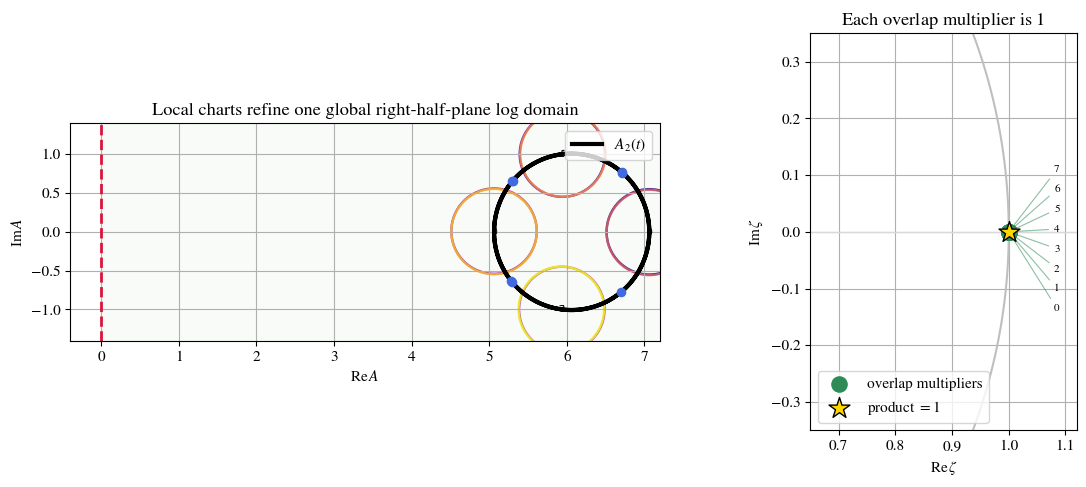

number of local charts = 8
root degree at K=2 = 4
computed product of overlap multipliers = 1+0j
max |zeta_i - 1| = 0.000e+00


In [27]:

# Build a refined chart-chain simulation inside the right half-plane.
# Every local chart uses the restriction of the same principal logarithm.
num_local_charts = 8
sample_ids = np.linspace(0, len(A_proof) - 1, num_local_charts + 1, dtype=int)
chart_centers = A_proof[sample_ids[:-1]]
chart_radius = min(0.55, 0.40 * sample_min_re)

# Overlap representative times between adjacent subcharts, plus the closing overlap.
overlap_ids = []
for j in range(num_local_charts):
    if j + 1 < num_local_charts:
        overlap_ids.append((sample_ids[j] + sample_ids[j+1]) // 2)
    else:
        overlap_ids.append(0)

# Same principal log branch on every local chart.
principal_arg = np.unwrap(np.angle(A_proof))
degree = 2 ** K_proof
root_branch = np.abs(A_proof) ** (1 / degree) * np.exp(1j * principal_arg / degree)

zeta_values = []
for m in overlap_ids:
    left_value = root_branch[m]
    right_value = root_branch[m]  # same restricted branch
    zeta_values.append(right_value / left_value)
zeta_values = np.array(zeta_values)
comparison_product = np.prod(zeta_values)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0))

ax = axes[0]
ax.set_aspect('equal', adjustable='box')
ax.axvspan(0, 7.5, color='#d9ead3', alpha=0.18)
ax.axvline(0, color='crimson', lw=2, ls='--')
ax.plot(A_proof.real, A_proof.imag, color='black', lw=3, label=r'$A_2(t)$')
for j, center in enumerate(chart_centers):
    circ = Circle((center.real, center.imag), chart_radius, fill=False,
                  ec=plt.cm.plasma(j / max(1, num_local_charts - 1)), lw=1.7, alpha=0.85)
    ax.add_patch(circ)
    ax.text(center.real, center.imag, str(j), ha='center', va='center', fontsize=8)
for m in overlap_ids[:-1]:
    ax.scatter([A_proof[m].real], [A_proof[m].imag], color='royalblue', s=35, zorder=5)
ax.set_xlim(-0.4, 7.2)
ax.set_ylim(-1.4, 1.4)
ax.set_xlabel(r'$\mathrm{Re}\,A$')
ax.set_ylabel(r'$\mathrm{Im}\,A$')
ax.set_title('Local charts refine one global right-half-plane log domain')
ax.legend(loc='upper right')

ax = axes[1]
unit = np.exp(1j * np.linspace(0, 2*np.pi, 400))
ax.set_aspect('equal', adjustable='box')
ax.plot(unit.real, unit.imag, color='0.75', lw=1.5)
ax.scatter(zeta_values.real, zeta_values.imag, color='seagreen', s=120, zorder=5, label='overlap multipliers')
for j, zeta in enumerate(zeta_values):
    ax.annotate(str(j), xy=(zeta.real, zeta.imag), xytext=(1.08, 0.035*(j-len(zeta_values)/2)),
                arrowprops=dict(arrowstyle='-', color='seagreen', alpha=0.55, lw=0.8), fontsize=8)
ax.scatter([1], [0], marker='*', color='gold', edgecolor='black', s=250, zorder=6, label=r'product $=1$')
ax.axhline(0, color='0.85', lw=1)
ax.axvline(0, color='0.85', lw=1)
ax.set_xlim(0.65, 1.12)
ax.set_ylim(-0.35, 0.35)
ax.set_xlabel(r'$\mathrm{Re}\,\zeta$')
ax.set_ylabel(r'$\mathrm{Im}\,\zeta$')
ax.set_title(r'Each overlap multiplier is $1$')
ax.legend(loc='lower left')

plt.tight_layout()
plt.show()

print(f'number of local charts = {num_local_charts}')
print(f'root degree at K=2 = {degree}')
print(f'computed product of overlap multipliers = {comparison_product:.12g}')
print(f'max |zeta_i - 1| = {np.max(np.abs(zeta_values - 1)):.3e}')


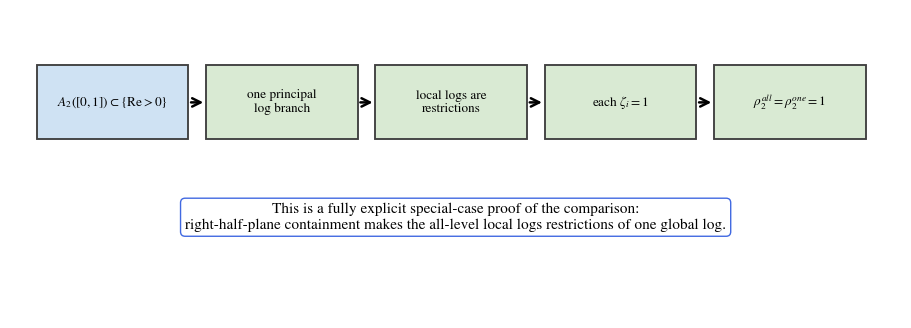

In [28]:

fig, ax = plt.subplots(figsize=(11.5, 4.0))
ax.axis('off')

proof_steps = [
    (r'$A_2([0,1])\subset\{\mathrm{Re}>0\}$', '#cfe2f3'),
    ('one principal\nlog branch', '#d9ead3'),
    ('local logs are\nrestrictions', '#d9ead3'),
    (r'each $\zeta_i=1$', '#d9ead3'),
    (r'$\rho_2^{all}=\rho_2^{one}=1$', '#d9ead3'),
]
xs = np.linspace(0.03, 0.79, len(proof_steps))
for (label, color), x in zip(proof_steps, xs):
    ax.add_patch(Rectangle((x, 0.58), 0.17, 0.24, fc=color, ec='0.25', lw=1.35))
    ax.text(x+0.085, 0.70, label, ha='center', va='center', fontsize=9.5)
for x0, x1 in zip(xs[:-1], xs[1:]):
    ax.add_patch(FancyArrowPatch((x0+0.17, 0.70), (x1, 0.70), arrowstyle='->', mutation_scale=15, lw=1.8))
ax.text(0.50, 0.29,
        'This is a fully explicit special-case proof of the comparison:\nright-half-plane containment makes the all-level local logs restrictions of one global log.',
        ha='center', bbox=dict(boxstyle='round', fc='white', ec='royalblue'))
plt.show()


### Generalized special-case family

The same proof works for every circle

$$
\gamma_r(t)=r e^{2\pi i t}
$$

as long as $r$ is small enough. Put $u=z^2$, so $|u|=r^2$. At level $K=2$,

$$
A_2(t)=f^2(\gamma_r(t))=6+4u+u^2.
$$

The same estimate gives

$$
\mathrm{Re}\,A_2(t)\geq 6-4r^2-r^4.
$$

So a sufficient condition for the right-half-plane log-branch comparison proof is

$$
6-4r^2-r^4>0.
$$

Equivalently, with $s=r^2$, we need $s^2+4s-6<0$, i.e.

$$
0\leq r < \sqrt{-2+\sqrt{10}}\approx 1.078.
$$

For all such radii, $A_2([0,1])$ lies in the right half-plane, all local logs can be restrictions of one principal log, and the comparison product is $1$.

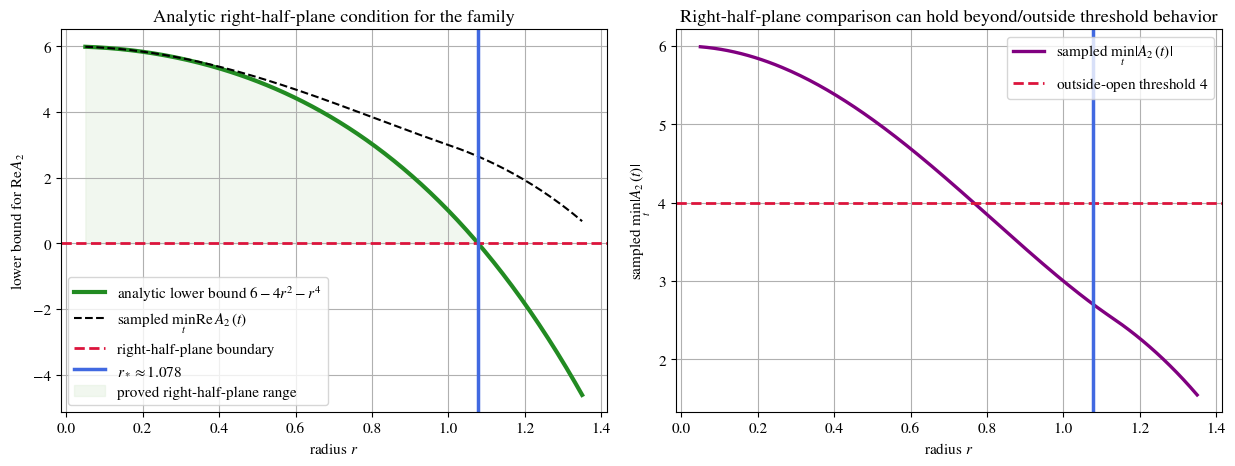

critical radius sqrt(-2+sqrt(10)) = 1.078089820084
For every r below this value, the same right-half-plane log-branch comparison proof applies.


In [29]:

# Generalized family gamma_r(t)=r exp(2 pi i t).
r_crit = np.sqrt(-2 + np.sqrt(10))
r_values = np.linspace(0.05, 1.35, 220)
lower_re_bound = 6 - 4*r_values**2 - r_values**4

# Numerical sampled minima for comparison with the analytic lower bound.
theta_family = np.linspace(0, 2*np.pi, 720)
min_re_sampled = []
min_abs_sampled = []
for r in r_values:
    loop_r = r * np.exp(1j * theta_family)
    A_r = iterate(loop_r, 2)
    min_re_sampled.append(A_r.real.min())
    min_abs_sampled.append(np.abs(A_r).min())
min_re_sampled = np.array(min_re_sampled)
min_abs_sampled = np.array(min_abs_sampled)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

ax = axes[0]
ax.plot(r_values, lower_re_bound, color='forestgreen', lw=3, label=r'analytic lower bound $6-4r^2-r^4$')
ax.plot(r_values, min_re_sampled, color='black', lw=1.5, ls='--', label=r'sampled $\min_t \mathrm{Re}\,A_2(t)$')
ax.axhline(0, color='crimson', lw=2, ls='--', label='right-half-plane boundary')
ax.axvline(r_crit, color='royalblue', lw=2.5, label=rf'$r_*\approx {r_crit:.3f}$')
ax.fill_between(r_values, lower_re_bound, 0, where=lower_re_bound>0, color='#d9ead3', alpha=0.35,
                label='proved right-half-plane range')
ax.set_xlabel('radius $r$')
ax.set_ylabel(r'lower bound for $\mathrm{Re}\,A_2$')
ax.set_title('Analytic right-half-plane condition for the family')
ax.legend(loc='lower left')

ax = axes[1]
ax.plot(r_values, min_abs_sampled, color='purple', lw=2.4, label=r'sampled $\min_t |A_2(t)|$')
ax.axhline(4, color='crimson', lw=2, ls='--', label='outside-open threshold $4$')
ax.axvline(r_crit, color='royalblue', lw=2.5)
ax.set_xlabel('radius $r$')
ax.set_ylabel(r'sampled $\min_t |A_2(t)|$')
ax.set_title('Right-half-plane comparison can hold beyond/outside threshold behavior')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f'critical radius sqrt(-2+sqrt(10)) = {r_crit:.12f}')
print('For every r below this value, the same right-half-plane log-branch comparison proof applies.')


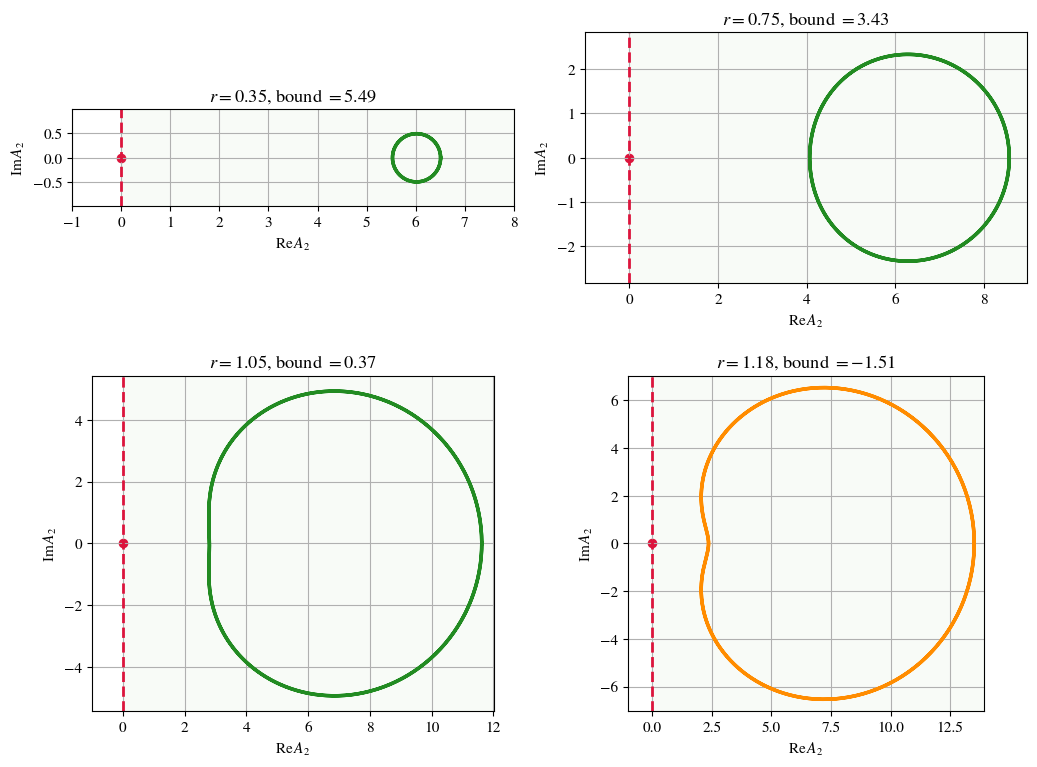

In [30]:

# Show several representative high images A_2(gamma_r) and the right half-plane boundary.
representative_r = [0.35, 0.75, 1.05, 1.18]
fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.0))
axes = axes.ravel()
for ax, r in zip(axes, representative_r):
    loop_r = r * np.exp(1j * theta_family)
    A_r = iterate(loop_r, 2)
    bound = 6 - 4*r*r - r**4
    ax.set_aspect('equal', adjustable='box')
    ax.axvspan(0, max(8, A_r.real.max()+0.5), color='#d9ead3', alpha=0.18)
    ax.axvline(0, color='crimson', lw=2, ls='--')
    ax.plot(A_r.real, A_r.imag, color='forestgreen' if bound > 0 else 'darkorange', lw=2.5)
    ax.scatter([0], [0], color='crimson', s=35)
    ax.set_title(rf'$r={r:.2f}$, bound $={bound:.2f}$')
    ax.set_xlabel(r'$\mathrm{Re}\,A_2$')
    ax.set_ylabel(r'$\mathrm{Im}\,A_2$')
    ax.set_xlim(min(-1, A_r.real.min()-0.4), max(8, A_r.real.max()+0.4))
    ax.set_ylim(A_r.imag.min()-0.5, A_r.imag.max()+0.5)
plt.tight_layout()
plt.show()


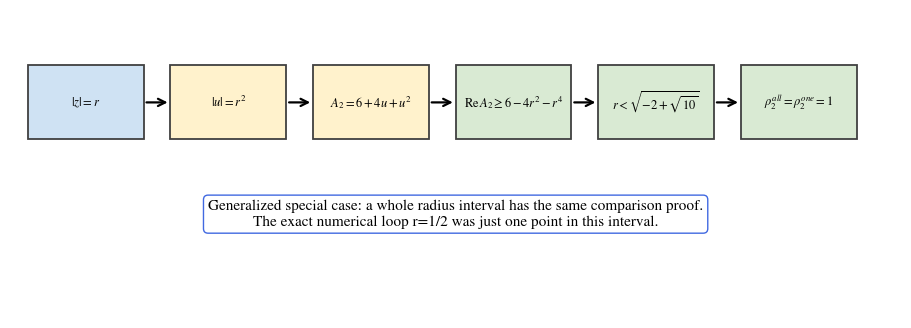

In [31]:

fig, ax = plt.subplots(figsize=(11.5, 4.0))
ax.axis('off')

steps = [
    (r'$|z|=r$', '#cfe2f3'),
    (r'$|u|=r^2$', '#fff2cc'),
    (r'$A_2=6+4u+u^2$', '#fff2cc'),
    (r'$\mathrm{Re}\,A_2\geq 6-4r^2-r^4$', '#d9ead3'),
    (r'$r<\sqrt{-2+\sqrt{10}}$', '#d9ead3'),
    (r'$\rho_2^{all}=\rho_2^{one}=1$', '#d9ead3'),
]
xs = np.linspace(0.02, 0.82, len(steps))
for (label, color), x in zip(steps, xs):
    ax.add_patch(Rectangle((x, 0.58), 0.13, 0.24, fc=color, ec='0.25', lw=1.3))
    ax.text(x+0.065, 0.70, label, ha='center', va='center', fontsize=9)
for x0, x1 in zip(xs[:-1], xs[1:]):
    ax.add_patch(FancyArrowPatch((x0+0.13, 0.70), (x1, 0.70), arrowstyle='->', mutation_scale=13, lw=1.6))
ax.text(0.50, 0.30,
        'Generalized special case: a whole radius interval has the same comparison proof.\nThe exact numerical loop r=1/2 was just one point in this interval.',
        ha='center', bbox=dict(boxstyle='round', fc='white', ec='royalblue'))
plt.show()


### Generalized special-case proof statement

#### Current result: right-half-plane family

For the family $\gamma_r(t)=r e^{2\pi i t}$ with
$$
0\leq r < r_{\mathrm{crit}}:=\sqrt{-2+\sqrt{10}}\approx 1.078,
$$
the high-level image $A_2(\gamma_r[0,1])$ is contained in the right half-plane
$\{\mathrm{Re}>0\}$.  A single principal log branch restricts to every local chart, every
overlap multiplier is $1$, and the high-level chain product agrees with the one-chart product.

#### Broader proof structure

The same mechanism operates at three widening levels of generality.

**Level 1 — Simply-connected image domain.**
If there exists a simply-connected open set $U\subset\mathbb{C}\setminus\{0\}$ with
$A_K(\gamma[0,1])\subset U$, a single branch of $\log$ exists on $U$ and restricts
consistently to every chart in any refinement $\Rightarrow$ each $\zeta_i=1$
$\Rightarrow\rho_K^{\mathrm{all}}=1=\rho_K^{\mathrm{one}}$.
*(Current formalization covers this level for circular loops with $r<r_{\mathrm{crit}}$.)*

**Level 2 — Winding-number zero.**
Even without a single simply-connected domain, if $A_K\circ\gamma$ has winding number
$0$ around $0$, then the product of all branch jumps is trivial:
$\prod_i\zeta_i=\exp(2\pi i\cdot 0)=1$.
Combined with $\rho^{\mathrm{all}}=(\prod_i\zeta_i)\cdot\rho^{\mathrm{one}}$, this gives
$\rho^{\mathrm{all}}=\rho^{\mathrm{one}}$ without requiring any domain containment.

**Level 3 — Analytic continuation uniqueness.**
The fully general theorem needs no geometric hypothesis: any two local chart log branches
that both extend the same normalized starting branch along $\gamma$ must agree at all
overlap points by the identity principle.  This is independent of domain shape or winding
number; it follows purely from uniqueness of analytic continuation.
*(This is exactly what the Lean structure* `ChartChainLocalLogsRestrictGlobal`
*formalizes — with the local-restriction hypothesis unproved in the general case.)*

#### More cases where Level 1 applies

| Loop family | Sufficient condition | Why $A_2\circ\gamma\subset\{\mathrm{Re}>0\}$ |
|---|---|---|
| Circles $r e^{2\pi it}$ | $r<r_{\mathrm{crit}}\approx 1.078$ | $\mathrm{Re}\,A_2\geq 6-4r^2-r^4>0$ |
| Ellipses $(a\cos 2\pi t,\, b\sin 2\pi t)$ | semi-axis $a<r_{\mathrm{crit}}$ | same Re bound holds pointwise |
| Small perturbations of any proved loop | $\|\gamma'-\gamma\|_\infty$ small | $A_2$ continuous; RHP image is open |
| Any loop inside $B(0,r_{\mathrm{crit}})$ | $\sup_t \lvert\gamma(t)\rvert < r_{\mathrm{crit}}$ | pointwise Re bound |

#### Cases where Level 2 applies but Level 1 fails

A figure-eight loop $\gamma$ in the basin whose two lobes wind $+1$ and $-1$ times
around $0$ under $A_K$ contributes $\zeta_i^{(+)}$ and $\zeta_i^{(-)}$ with
$\zeta_i^{(+)}\cdot\zeta_i^{(-)}=1$, so $\prod\zeta_i=1$ even though no
single simply-connected domain contains the whole image.

More generally, any loop $\gamma$ for which $A_K\circ\gamma$ is null-homotopic in
$\mathbb{C}^*$ satisfies Level 2, regardless of whether $A_K\circ\gamma$ is contained
in any particular half-plane.

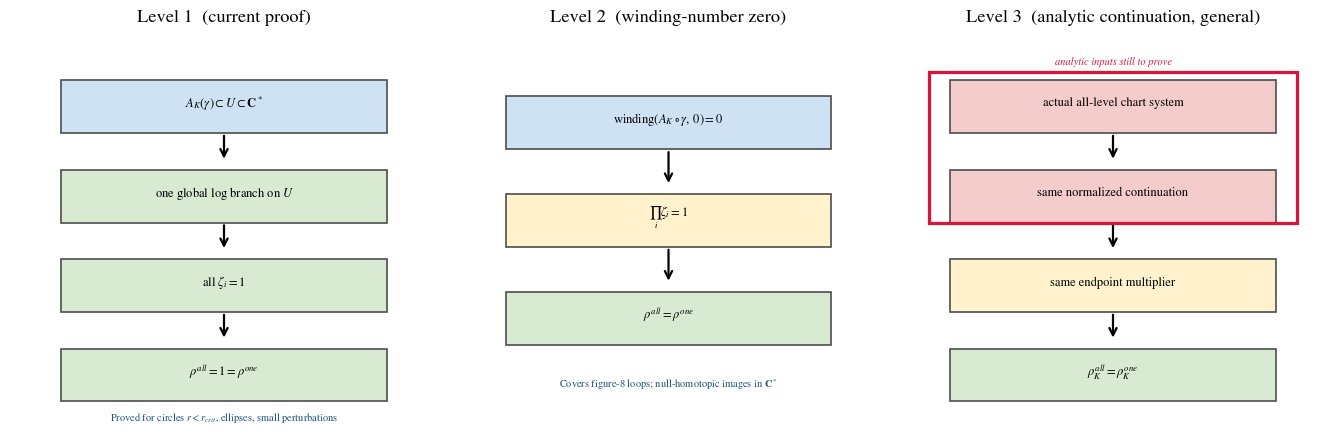

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))

def draw_box(ax, y, label, color):
    ax.add_patch(Rectangle((0.12, y - 0.075), 0.76, 0.13,
                            fc=color, ec='0.3', lw=1.2))
    ax.text(0.50, y, label, ha='center', va='center', fontsize=9)

ys4 = np.linspace(0.82, 0.16, 4)

# Level 1: simply-connected domain (current proof)
ax = axes[0]
ax.axis('off')
ax.set_title('Level 1  (current proof)')
level1 = [
    (r'$A_K(\gamma)\subset U\subset\mathbf{C}^*$', '#cfe2f3'),
    (r'one global log branch on $U$', '#d9ead3'),
    (r'all $\zeta_i=1$', '#d9ead3'),
    (r'$\rho^{all}=1=\rho^{one}$', '#d9ead3'),
]
for (lab, col), y in zip(level1, ys4):
    draw_box(ax, y, lab, col)
for y0, y1 in zip(ys4[:-1], ys4[1:]):
    ax.add_patch(FancyArrowPatch((0.50, y0 - 0.075), (0.50, y1 + 0.075),
                                 arrowstyle='->', mutation_scale=13, lw=1.6))
ax.text(0.50, 0.04, r'Proved for circles $r<r_{crit}$, ellipses, small perturbations',
        ha='center', fontsize=7.5, color='#1a5276')

# Level 2: winding-number zero
ax = axes[1]
ax.axis('off')
ax.set_title('Level 2  (winding-number zero)')
level2 = [
    (r'winding$(A_K\circ\gamma,\;0)=0$', '#cfe2f3'),
    (r'$\prod_i\zeta_i = 1$', '#fff2cc'),
    (r'$\rho^{all}=\rho^{one}$', '#d9ead3'),
]
ys3 = np.linspace(0.78, 0.30, 3)
for (lab, col), y in zip(level2, ys3):
    draw_box(ax, y, lab, col)
for y0, y1 in zip(ys3[:-1], ys3[1:]):
    ax.add_patch(FancyArrowPatch((0.50, y0 - 0.075), (0.50, y1 + 0.075),
                                 arrowstyle='->', mutation_scale=13, lw=1.6))
ax.text(0.50, 0.12, r'Covers figure-8 loops; null-homotopic images in $\mathbf{C}^*$',
        ha='center', fontsize=7.5, color='#1a5276')

# Level 3: analytic continuation uniqueness (remaining)
ax = axes[2]
ax.axis('off')
ax.set_title('Level 3  (analytic continuation, general)')
level3 = [
    (r'actual all-level chart system', '#f4cccc'),
    (r'same normalized continuation', '#f4cccc'),
    (r'same endpoint multiplier', '#fff2cc'),
    (r'$\rho_K^{all}=\rho_K^{one}$', '#d9ead3'),
]
for (lab, col), y in zip(level3, ys4):
    draw_box(ax, y, lab, col)
for y0, y1 in zip(ys4[:-1], ys4[1:]):
    ax.add_patch(FancyArrowPatch((0.50, y0 - 0.075), (0.50, y1 + 0.075),
                                 arrowstyle='->', mutation_scale=13, lw=1.6))
# red frame wrapping the two ANALYTIC INPUT boxes (top two)
bot = ys4[1] - 0.075   # bottom of box 1 = 0.505 approx
top = ys4[0] + 0.075   # top of box 0    = 0.895 approx
ax.add_patch(Rectangle((0.07, bot), 0.86, top - bot,
                        fill=False, ec='crimson', lw=2.3))
ax.text(0.50, top + 0.02, 'analytic inputs still to prove',
        ha='center', fontsize=7.5, color='crimson', style='italic')

plt.tight_layout()
plt.show()

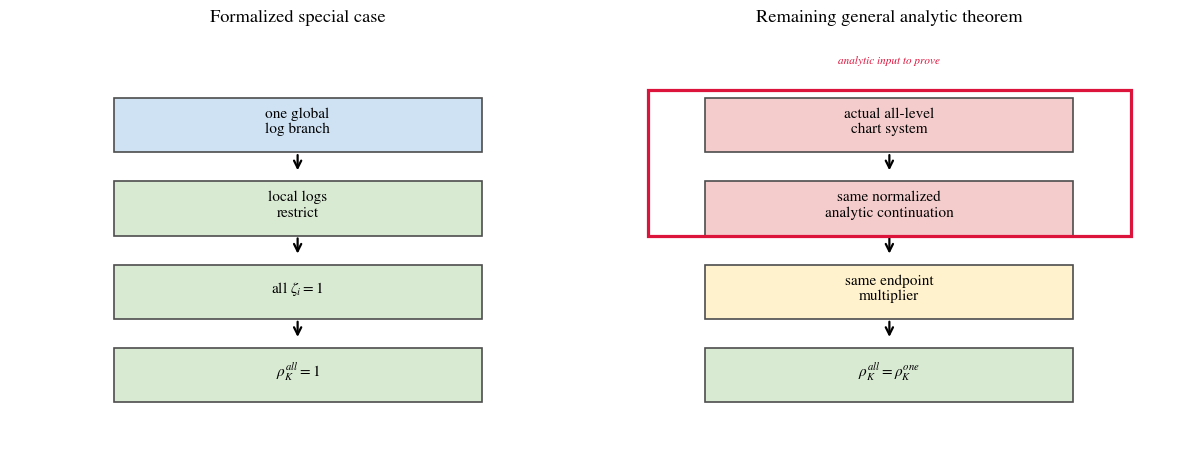

In [33]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))

# Left: current proved special case.
ax = axes[0]
ax.axis('off')
special = [
    ('one global\nlog branch', '#cfe2f3'),
    ('local logs\nrestrict', '#d9ead3'),
    (r'all $\zeta_i=1$', '#d9ead3'),
    (r'$\rho_K^{all}=1$', '#d9ead3'),
]
ys = np.linspace(0.78, 0.18, len(special))
for (label, color), y in zip(special, ys):
    ax.add_patch(Rectangle((0.18, y-0.075), 0.64, 0.13, fc=color, ec='0.3', lw=1.2))
    ax.text(0.50, y, label, ha='center', va='center')
for y0, y1 in zip(ys[:-1], ys[1:]):
    ax.add_patch(FancyArrowPatch((0.50, y0-0.075), (0.50, y1+0.075), arrowstyle='->', mutation_scale=13, lw=1.6))
ax.set_title('Formalized special case')

# Right: remaining general case.
ax = axes[1]
ax.axis('off')
general = [
    ('actual all-level\nchart system', '#f4cccc'),
    ('same normalized\nanalytic continuation', '#f4cccc'),
    ('same endpoint\nmultiplier', '#fff2cc'),
    (r'$\rho_K^{all}=\rho_K^{one}$', '#d9ead3'),
]
for (label, color), y in zip(general, ys):
    ax.add_patch(Rectangle((0.18, y-0.075), 0.64, 0.13, fc=color, ec='0.3', lw=1.2))
    ax.text(0.50, y, label, ha='center', va='center')
for y0, y1 in zip(ys[:-1], ys[1:]):
    ax.add_patch(FancyArrowPatch((0.50, y0-0.075), (0.50, y1+0.075), arrowstyle='->', mutation_scale=13, lw=1.6))
# red frame wrapping the top two boxes (the analytic inputs)
ax.add_patch(Rectangle((0.08, 0.505), 0.84, 0.855-0.505, fill=False, ec='crimson', lw=2.3))
ax.text(0.50, 0.92, 'analytic input to prove', ha='center', fontsize=8,
        color='crimson', style='italic')
ax.set_title('Remaining general analytic theorem')

plt.tight_layout()
plt.show()


### Level 3 example: constructed positive case

#### Setup

Take the actual map already in the proof,
$$
A_2(z) = z^4 + 4z^2 + 6 \quad \text{(second iterate of } q_c(z)=z^2+2 \text{ at } c=2\text{)},
$$
and the loop $\gamma(t) = 2\,e^{2\pi i t}$, $t\in[0,1]$, with starting germ
$b_0 = \log A_2(2) = \log 38 \in \mathbf{R}$.

#### Why Level 1 fails

The zeros of $A_2(z)=z^4+4z^2+6=0$ satisfy $z^2 = -2\pm i\sqrt{2}$, giving $|z| = 6^{1/4}\approx 1.565 < 2$. All **four** zeros lie inside $\gamma$. By the argument principle the image $A_2(\gamma)$ winds **4 times** around $0$. No simply-connected open subset of $\mathbf{C}^*$ contains a curve with positive winding number. **Level 1 fails.**

#### Explicit branch-cut crossings

The curve $A_2(\gamma)$ crosses the negative real axis at
$$
\theta = \tfrac{\pi}{3},\;\tfrac{2\pi}{3},\;\tfrac{4\pi}{3},\;\tfrac{5\pi}{3}
\quad\Longrightarrow\quad A_2\!\left(2e^{i\theta}\right) = 6 - r^4 = 6 - 16 = -10.
$$
At each crossing the local log branch must decide whether to continue the argument upward (past $+\pi$) or snap back downward (to $-\pi$). A naive principal log jumps $-2\pi$ each time; the correct analytic continuation does not jump.

#### Level 3 argument

| Step | Tool |
|------|------|
| Fix starting germ $b_0 = \log 38$ at $z_0=2$ | definition |
| Both systems analytically extend $b_0$ along $\gamma$ | by construction |
| At each overlap $O_{k,k+1}$: both branches are analytic and agree on an open set | overlap condition |
| Therefore $b_{k+1} = b_k\!\mid_{O_{k,k+1}}$ on the whole overlap | **identity principle** |
| The endpoint value is the unique continuation: $\mathrm{Im}(b) = 8\pi$ | induction along chain |
| $\rho^{all} = e^{i \cdot 8\pi} = 1 = \rho^{one}$ | comparison proved |

The naive log gives 4 jumps of $-2\pi$ that cancel to $0$; the correct continuation ramps smoothly to $8\pi$. Both computations give $e^{i\cdot 8\pi}=1$, but only the Level 3 argument guarantees the all-chain and one-chart systems agree at every intermediate step.

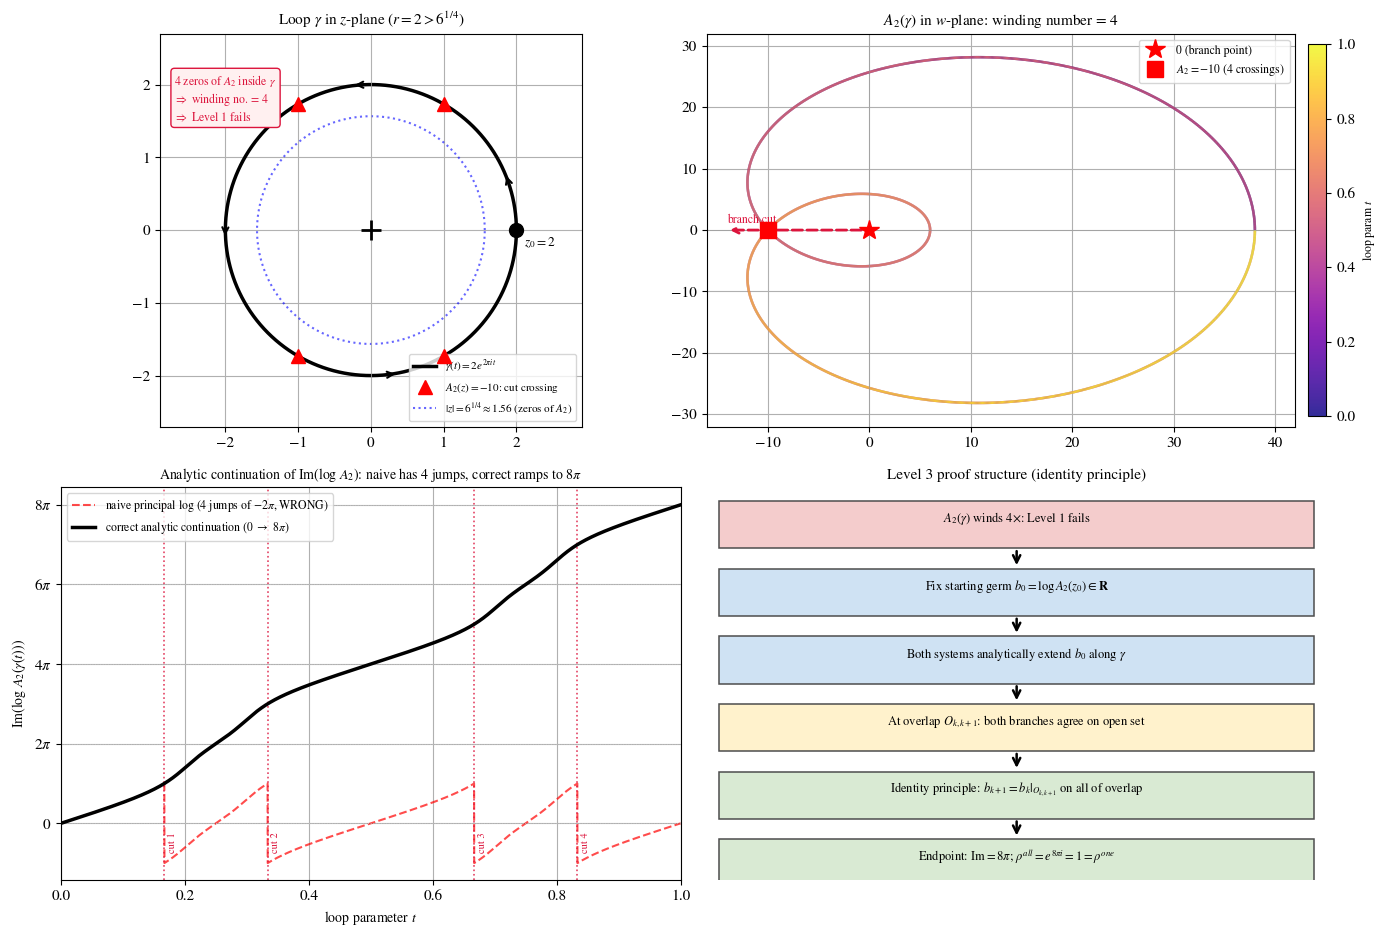

In [34]:
from matplotlib.collections import LineCollection

theta_v = np.linspace(0, 2 * np.pi, 5000, endpoint=True)
t_v     = theta_v / (2 * np.pi)
z_v     = 2.0 * np.exp(1j * theta_v)
w_v     = z_v**4 + 4 * z_v**2 + 6          # A_2(z)

phi_cont  = np.unwrap(np.angle(w_v))        # 0 -> 8*pi
phi_naive = np.angle(w_v)                   # principal log, has 4 jumps of -2*pi

# 4 branch-cut crossings (theta = pi/3, 2pi/3, 4pi/3, 5pi/3)
theta_cross = np.array([np.pi/3, 2*np.pi/3, 4*np.pi/3, 5*np.pi/3])
t_cross     = theta_cross / (2 * np.pi)

fig, axes = plt.subplots(2, 2, figsize=(14, 9.5))

# ── Panel 1: gamma in z-plane ────────────────────────────────────────────────
ax = axes[0, 0]
ax.set_aspect('equal')
th = np.linspace(0, 2 * np.pi, 1000)
ax.plot(2 * np.cos(th), 2 * np.sin(th), 'k-', lw=2.5,
        label=r'$\gamma(t)=2e^{2\pi it}$')
for ang in [0.3, 1.6, 3.1, 4.8]:
    z0, dz = 2*np.exp(1j*ang), 0.2j*np.exp(1j*ang)
    ax.annotate('', xy=(z0.real+dz.real, z0.imag+dz.imag), xytext=(z0.real, z0.imag),
                arrowprops=dict(arrowstyle='->', color='k', lw=1.5), zorder=15)
for i, tc in enumerate(theta_cross):
    zc = 2 * np.exp(1j * tc)
    ax.plot(zc.real, zc.imag, 'r^', ms=10, zorder=20,
            label=r'$A_2(z)=-10$: cut crossing' if i == 0 else None)
ax.plot(2, 0, 'ko', ms=10, zorder=20)
ax.text(2.1, -0.22, r'$z_0=2$', fontsize=9.5)
ax.plot(0, 0, 'k+', ms=14, mew=2, zorder=5)
zeros_r = 6**0.25
circ_z = zeros_r * np.exp(1j * th)
ax.plot(circ_z.real, circ_z.imag, 'b:', lw=1.5, alpha=0.6,
        label=r'$|z|=6^{1/4}\approx 1.56$ (zeros of $A_2$)')
ax.text(-2.7, 1.5,
        r'4 zeros of $A_2$ inside $\gamma$' + '\n' +
        r'$\Rightarrow$ winding no. = 4' + '\n' + r'$\Rightarrow$ Level 1 fails',
        fontsize=8.5, color='crimson',
        bbox=dict(boxstyle='round', fc='#fff0f0', ec='crimson'))
ax.axhline(0, c='0.7', lw=0.5); ax.axvline(0, c='0.7', lw=0.5)
ax.set_xlim(-2.9, 2.9); ax.set_ylim(-2.7, 2.7)
ax.legend(loc='lower right', fontsize=8)
ax.set_title(r'Loop $\gamma$ in $z$-plane $(r=2 > 6^{1/4})$', fontsize=11)

# ── Panel 2: A_2(gamma) in w-plane ──────────────────────────────────────────
ax = axes[0, 1]
points = np.column_stack([w_v.real, w_v.imag]).reshape(-1, 1, 2)
segs   = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segs, cmap='plasma', lw=1.8, alpha=0.85,
                    norm=plt.Normalize(0, 1))
lc.set_array(t_v[:-1])
ax.add_collection(lc)
# Branch cut arrow
ax.annotate('', xy=(-14, 0), xytext=(-0.5, 0),
            arrowprops=dict(arrowstyle='->', color='crimson', lw=2,
                            linestyle='dashed', connectionstyle='arc3,rad=0'))
ax.text(-14, 1.2, r'branch cut', fontsize=8.5, color='crimson')
ax.plot(0,   0, 'r*', ms=15, zorder=25, label=r'0 (branch point)')
ax.plot(-10, 0, 'rs', ms=11, zorder=25, label=r'$A_2=-10$ (4 crossings)')
ax.axhline(0, c='0.6', lw=0.4); ax.axvline(0, c='0.6', lw=0.4)
ax.set_xlim(-16, 42); ax.set_ylim(-32, 32)
ax.legend(loc='upper right', fontsize=8.5)
cb = plt.colorbar(lc, ax=ax, fraction=0.03, pad=0.02)
cb.set_label(r'loop param $t$', fontsize=8.5)
ax.set_title(r'$A_2(\gamma)$ in $w$-plane: winding number = 4', fontsize=11)

# ── Panel 3: Im(log A_2) along the loop ──────────────────────────────────────
ax = axes[1, 0]
ax.plot(t_v, phi_naive, 'r--', lw=1.5, alpha=0.7,
        label=r'naive principal log (4 jumps of $-2\pi$, WRONG)')
ax.plot(t_v, phi_cont,  'k-',  lw=2.5, zorder=10,
        label=r'correct analytic continuation (0 $\to$ $8\pi$)')
for i, tc in enumerate(t_cross):
    ax.axvline(tc, c='crimson', lw=1.2, ls=':', alpha=0.8)
    ax.text(tc + 0.005, -2.2, f'cut {i+1}', fontsize=7.5, color='crimson', rotation=90)
for k in range(5):
    ax.axhline(2 * k * np.pi, c='0.75', lw=0.7, ls=':')
ax.set_yticks([2 * k * np.pi for k in range(5)])
ax.set_yticklabels([r'$0$', r'$2\pi$', r'$4\pi$', r'$6\pi$', r'$8\pi$'])
ax.set_xlabel(r'loop parameter $t$', fontsize=10)
ax.set_ylabel(r'$\mathrm{Im}(\log\,A_2(\gamma(t)))$', fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(-4.5, 26.5)
ax.legend(fontsize=8.5, loc='upper left')
ax.set_title(
    r'Analytic continuation of $\mathrm{Im}(\log\,A_2)$: naive has 4 jumps, correct ramps to $8\pi$',
    fontsize=10)

# ── Panel 4: identity-principle proof flow ───────────────────────────────────
ax = axes[1, 1]
ax.axis('off')
ax.set_title('Level 3 proof structure (identity principle)', fontsize=11)
proof = [
    (r'$A_2(\gamma)$ winds 4$\times$: Level 1 fails', '#f4cccc'),
    (r'Fix starting germ $b_0 = \log A_2(z_0) \in \mathbf{R}$', '#cfe2f3'),
    (r'Both systems analytically extend $b_0$ along $\gamma$', '#cfe2f3'),
    (r'At overlap $O_{k,k+1}$: both branches agree on open set', '#fff2cc'),
    (r'Identity principle: $b_{k+1} = b_k|_{O_{k,k+1}}$ on all of overlap', '#d9ead3'),
    (r'Endpoint: $\mathrm{Im}=8\pi$; $\rho^{all}=e^{8\pi i}=1=\rho^{one}$', '#d9ead3'),
]
ys = np.linspace(0.92, 0.06, len(proof))
for (lab, col), y in zip(proof, ys):
    ax.add_patch(Rectangle((0.02, y - 0.075), 0.96, 0.12,
                            fc=col, ec='0.3', lw=1.1))
    ax.text(0.50, y, lab, ha='center', va='center', fontsize=9)
for y0, y1 in zip(ys[:-1], ys[1:]):
    ax.add_patch(FancyArrowPatch((0.50, y0 - 0.075), (0.50, y1 + 0.047),
                                 arrowstyle='->', mutation_scale=13, lw=1.8))

plt.tight_layout()
plt.show()

### Next Lean target

A plausible next interface is:

```lean
ActualHighChartChainsCompareByAnalyticContinuation
```

with fields asserting that the actual all-level high chain and the canonical one-chart high chain continue the same normalized starting branch along the same basin loop. From that, uniqueness of analytic continuation should produce `HighEscapingChartChainProductComparisonData`.